# 🏢 Project 3: Clustering — WiFi Indoor Localization (UJIndoorLoc)

**CS3061 — Machine Learning | UTEC 2026-0**

---

## Descripción del Proyecto

En entornos interiores donde las señales GPS no están disponibles (como centros comerciales y edificios de oficinas), el posicionamiento basado en huellas digitales WiFi (RSSI) es una tecnología principal. Este proyecto utiliza el conocido dataset **UJIndoorLoc** para aplicar algoritmos de **clustering** que permitan analizar las características de las señales WiFi recibidas en diferentes ubicaciones y las áreas potenciales donde se encuentra un usuario.

### Objetivos:
1. **Agrupar automáticamente** puntos de señal en diferentes clústeres usando algoritmos de clustering (K-Means, DBSCAN, Agglomerative, Mean Shift, GMM)
2. **Visualizar** las señales de alta dimensionalidad usando técnicas de reducción de dimensionalidad (PCA, t-SNE)
3. **Evaluar** la calidad del clustering usando métricas internas y externas

### Estructura del Notebook:
1. Importación de librerías
2. Carga y exploración de datos
3. Preprocesamiento de datos
4. Reducción de dimensionalidad (PCA, t-SNE)
5. Determinación del número óptimo de clústeres
6. Algoritmos de clustering (K-Means, DBSCAN, Agglomerative, Mean Shift, GMM)
7. Evaluación interna (Silhouette, Davies-Bouldin, Dunn Index)
8. Evaluación externa (Rand Index, Homogeneity, Completeness)
9. Comparación de modelos y conclusiones

## 1. Importación de Librerías
Se importan todas las librerías necesarias para el análisis de datos, visualización, reducción de dimensionalidad, clustering y evaluación de modelos.

In [72]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Algoritmos de Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift
from sklearn.mixture import GaussianMixture

# Métricas de Evaluación Interna
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Métricas de Evaluación Externa
from sklearn.metrics import (
    rand_score, adjusted_rand_score,
    homogeneity_score, completeness_score, v_measure_score
)

# Utilidades
from scipy.spatial.distance import cdist
from collections import Counter

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente.")

✅ Todas las librerías importadas correctamente.


## 2. Carga de Datos
Se cargan los conjuntos de entrenamiento y validación del dataset UJIndoorLoc. Este dataset contiene 520 columnas WAP (Wireless Access Points) con valores RSSI (Received Signal Strength Indicator), además de columnas de metadatos como coordenadas (LONGITUDE, LATITUDE), piso (FLOOR), edificio (BUILDINGID), entre otros.

In [73]:
# ============================================================
# 2. CARGA DE DATOS
# ============================================================
import os
import subprocess
import pandas as pd
import shutil

# --- Detectar entorno ---
IN_COLAB = False
try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass

# Forzar IN_COLAB a False si estamos en un entorno local seguro (por si acaso google.colab está instalado localmente)
if os.path.exists('UJIndoorLoc/trainingData.csv'):
    IN_COLAB = False

if IN_COLAB:
    # En Colab: clonar el repositorio con los datos solo si no existen
    if not os.path.exists('UJIndoorLoc/trainingData.csv'):
        print("📥 Clonando repositorio con datos...")
        # Limpiar directorio temporal si existe
        if os.path.exists('/content/repo_tmp'):
            shutil.rmtree('/content/repo_tmp')
            
        subprocess.run(['git', 'clone', 'https://github.com/Juan-Velo/Machine_Learning_p3.git', '/content/repo_tmp'],
                       capture_output=True, text=True)
        
        # Si el repo tiene los archivos, copiarlos
        if os.path.exists('/content/repo_tmp/UJIndoorLoc'):
            if os.path.exists('UJIndoorLoc'):
                shutil.rmtree('UJIndoorLoc')
            shutil.copytree('/content/repo_tmp/UJIndoorLoc', 'UJIndoorLoc')
            print("✅ Datos copiados desde el repositorio")
        else:
            # Si no están en el repo, indicar que los suba manualmente
            print("⚠️  No se pudieron descargar los datos automáticamente.")
            
            # Intentar montar Drive como fallback
            try:
                from google.colab import drive  # type: ignore
                drive.mount('/content/drive')
                # Intentar buscar en Drive
                drive_paths = [
                    '/content/drive/MyDrive/Machine_Learning/machine_p3/UJIndoorLoc',
                    '/content/drive/MyDrive/machine_p3/UJIndoorLoc',
                    '/content/drive/MyDrive/UJIndoorLoc',
                ]
                
                found = False
                for dp in drive_paths:
                    if os.path.exists(dp):
                        if os.path.exists('UJIndoorLoc'):
                            shutil.rmtree('UJIndoorLoc')
                        shutil.copytree(dp, 'UJIndoorLoc')
                        print(f"✅ Datos encontrados y copiados desde: {dp}")
                        found = True
                        break
                
                if not found:
                    print("⚠️ No se encontraron los datos en Drive.")
                    print("Por favor, sube manualmente la carpeta 'UJIndoorLoc' con los archivos CSV.")
            except Exception as e:
                print(f"Error al intentar montar Drive: {e}")

else:
    print("✅ Ejecutando en entorno local")

# --- Cargar datos ---
# Verificar si los archivos existen antes de leer
if os.path.exists('UJIndoorLoc/trainingData.csv') and os.path.exists('UJIndoorLoc/validationData.csv'):
    df_train = pd.read_csv('UJIndoorLoc/trainingData.csv')
    df_val = pd.read_csv('UJIndoorLoc/validationData.csv')

    # Columnas WAP y metadatos
    wap_cols = [col for col in df_train.columns if col.startswith('WAP')]
    meta_cols = ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID',
                 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']

    print(f"\n📊 Dataset de Entrenamiento: {df_train.shape[0]} muestras × {df_train.shape[1]} columnas")
    print(f"📊 Dataset de Validación:    {df_val.shape[0]} muestras × {df_val.shape[1]} columnas")
    print(f"📡 Número de WAPs:           {len(wap_cols)}")
    print(f"📋 Columnas de metadatos:    {meta_cols}")
    print(f"\n{'='*60}")
    print("Primeras filas del dataset de entrenamiento:")
    display(df_train.head()) # Usar display() para mejor visualización en notebooks
else:
    print("❌ ERROR: No se encontraron los archivos de datos 'trainingData.csv' y 'validationData.csv' en la carpeta 'UJIndoorLoc/'.")
    print("Asegúrate de que la carpeta 'UJIndoorLoc' esté en el mismo directorio que este notebook.")

✅ Ejecutando en entorno local

📊 Dataset de Entrenamiento: 19937 muestras × 529 columnas
📊 Dataset de Validación:    1111 muestras × 529 columnas
📡 Número de WAPs:           520
📋 Columnas de metadatos:    ['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']

Primeras filas del dataset de entrenamiento:


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


## 3. Análisis Exploratorio de Datos (EDA)
Exploración detallada del dataset para comprender su estructura, distribución de clases y características de las señales WiFi.

In [74]:
# ============================================================
# 3.1 INFORMACIÓN GENERAL DEL DATASET
# ============================================================
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
print(f"\n📐 Dimensiones: {df_train.shape}")
print(f"📊 Tipos de datos:\n{df_train.dtypes.value_counts()}")
print(f"\n🔍 Valores nulos: {df_train.isnull().sum().sum()}")
print(f"\n📈 Estadísticas descriptivas de las columnas de metadatos:")
df_train[meta_cols].describe().round(2)

INFORMACIÓN GENERAL DEL DATASET

📐 Dimensiones: (19937, 529)
📊 Tipos de datos:
int64      527
float64      2
Name: count, dtype: int64

🔍 Valores nulos: 0

📈 Estadísticas descriptivas de las columnas de metadatos:


,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
count,19937.00,19937.00,19937.00,19937.00,19937.00,19937.00,19937.00,19937.00,1.993700e+04
mean,-7464.28,4864870.89,1.67,1.21,148.43,1.83,9.07,13.02,1.371421e+09
std,123.40,66.93,1.22,0.83,58.34,0.37,4.99,5.36,5.572054e+05
min,-7691.34,4864745.75,0.00,0.00,1.00,1.00,1.00,1.00,1.369909e+09
25%,-7594.74,4864820.88,1.00,0.00,110.00,2.00,5.00,8.00,1.371056e+09
50%,-7423.06,4864852.15,2.00,1.00,129.00,2.00,11.00,13.00,1.371716e+09
75%,-7359.19,4864929.89,3.00,2.00,207.00,2.00,13.00,14.00,1.371721e+09
max,-7300.82,4865016.69,4.00,2.00,254.00,2.00,18.00,24.00,1.371738e+09


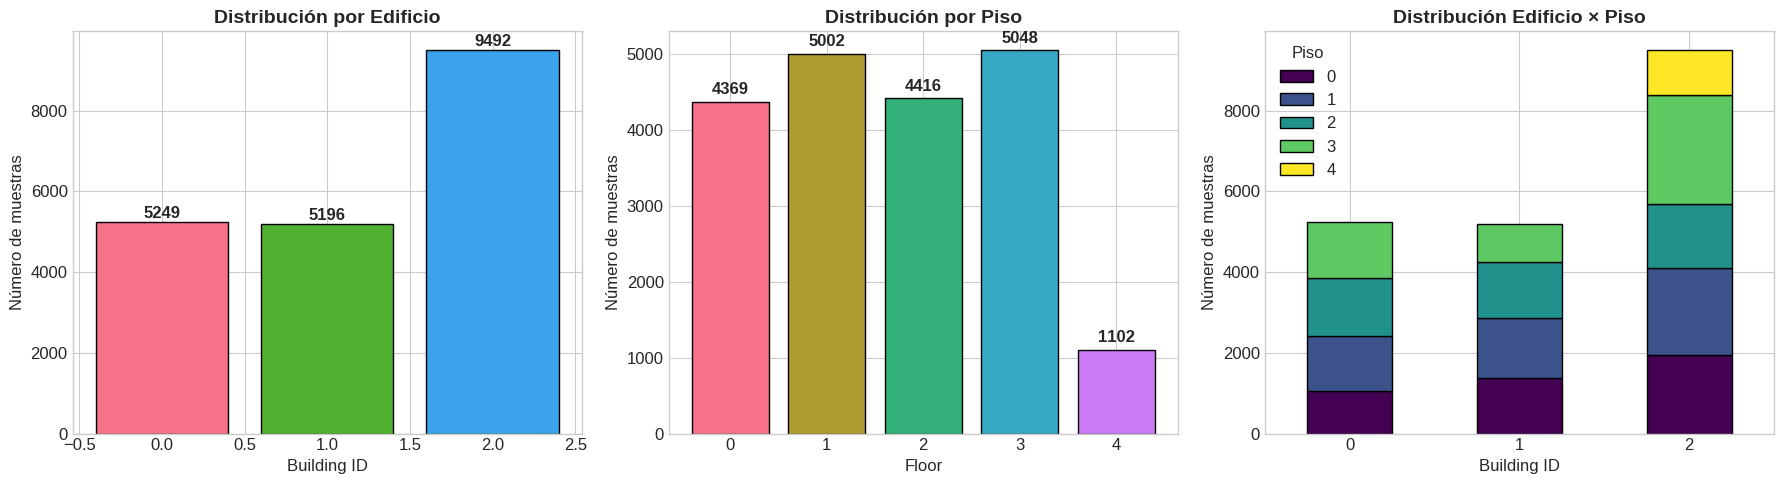


📊 Tabla cruzada Edificio × Piso:
FLOOR          0     1     2     3     4
BUILDINGID                              
0           1059  1356  1443  1391     0
1           1368  1484  1396   948     0
2           1942  2162  1577  2709  1102


In [75]:
# ============================================================
# 3.2 DISTRIBUCIÓN DE EDIFICIOS Y PISOS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución por edificio
building_counts = df_train['BUILDINGID'].value_counts().sort_index()
axes[0].bar(building_counts.index, building_counts.values, color=sns.color_palette("husl", 3), edgecolor='black')
axes[0].set_title('Distribución por Edificio', fontweight='bold')
axes[0].set_xlabel('Building ID')
axes[0].set_ylabel('Número de muestras')
for i, v in enumerate(building_counts.values):
    axes[0].text(building_counts.index[i], v + 100, str(v), ha='center', fontweight='bold')

# Distribución por piso
floor_counts = df_train['FLOOR'].value_counts().sort_index()
axes[1].bar(floor_counts.index, floor_counts.values, color=sns.color_palette("husl", len(floor_counts)), edgecolor='black')
axes[1].set_title('Distribución por Piso', fontweight='bold')
axes[1].set_xlabel('Floor')
axes[1].set_ylabel('Número de muestras')
for i, v in enumerate(floor_counts.values):
    axes[1].text(floor_counts.index[i], v + 100, str(v), ha='center', fontweight='bold')

# Distribución por edificio y piso (stacked)
cross_tab = pd.crosstab(df_train['BUILDINGID'], df_train['FLOOR'])
cross_tab.plot(kind='bar', stacked=True, ax=axes[2], colormap='viridis', edgecolor='black')
axes[2].set_title('Distribución Edificio × Piso', fontweight='bold')
axes[2].set_xlabel('Building ID')
axes[2].set_ylabel('Número de muestras')
axes[2].legend(title='Piso')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\n📊 Tabla cruzada Edificio × Piso:")
print(cross_tab)

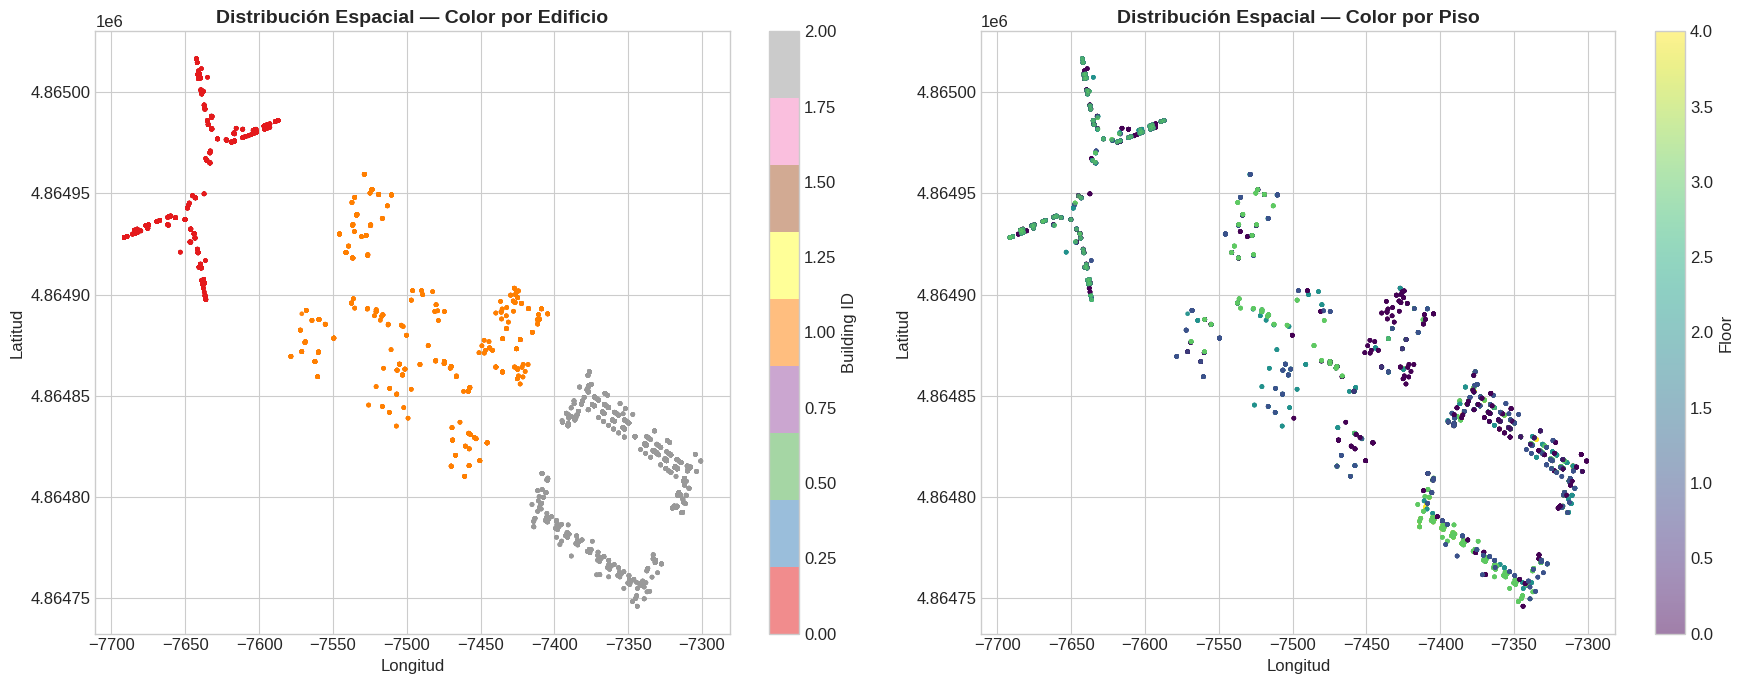

In [76]:
# ============================================================
# 3.3 DISTRIBUCIÓN ESPACIAL DE LOS PUNTOS (LONGITUD vs LATITUD)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorear por Edificio
scatter1 = axes[0].scatter(df_train['LONGITUDE'], df_train['LATITUDE'],
                           c=df_train['BUILDINGID'], cmap='Set1', alpha=0.5, s=5)
axes[0].set_title('Distribución Espacial — Color por Edificio', fontweight='bold')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Building ID')

# Colorear por Piso
scatter2 = axes[1].scatter(df_train['LONGITUDE'], df_train['LATITUDE'],
                           c=df_train['FLOOR'], cmap='viridis', alpha=0.5, s=5)
axes[1].set_title('Distribución Espacial — Color por Piso', fontweight='bold')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Floor')

plt.tight_layout()
plt.show()

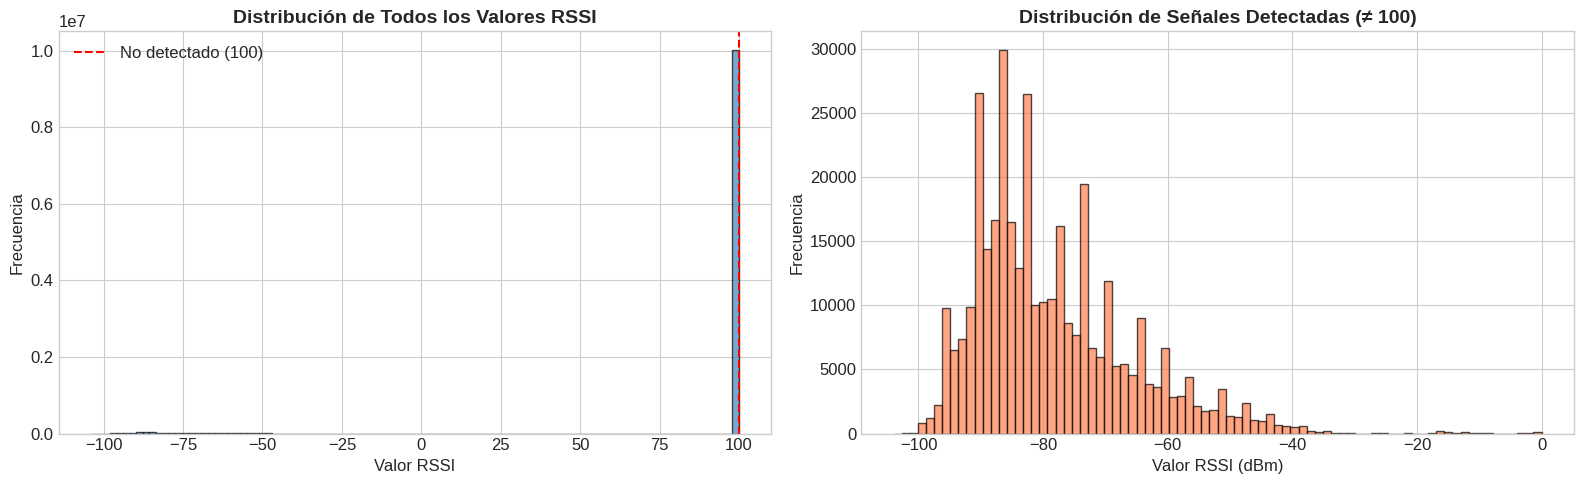

📡 Total de lecturas WAP:           10,367,240
📡 Señales no detectadas (=100):    10,008,477 (96.5%)
📡 Señales detectadas:              358,763 (3.5%)
📡 Rango de señales detectadas:     [-104, 0] dBm
📡 Media de señales detectadas:     -78.5 dBm


In [77]:
# ============================================================
# 3.4 ANÁLISIS DE SEÑALES RSSI (WAP)
# ============================================================
wap_data = df_train[wap_cols]

# Distribución de valores RSSI (excluyendo 100 = no detectado)
all_rssi = wap_data.values.flatten()
detected_rssi = all_rssi[all_rssi != 100]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de todos los valores RSSI
axes[0].hist(all_rssi, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Todos los Valores RSSI', fontweight='bold')
axes[0].set_xlabel('Valor RSSI')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(x=100, color='red', linestyle='--', label='No detectado (100)')
axes[0].legend()

# Histograma solo de señales detectadas
axes[1].hist(detected_rssi, bins=80, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Señales Detectadas (≠ 100)', fontweight='bold')
axes[1].set_xlabel('Valor RSSI (dBm)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas
total_values = wap_data.size
no_signal = (wap_data == 100).sum().sum()
print(f"📡 Total de lecturas WAP:           {total_values:,}")
print(f"📡 Señales no detectadas (=100):    {no_signal:,} ({no_signal/total_values*100:.1f}%)")
print(f"📡 Señales detectadas:              {total_values - no_signal:,} ({(total_values - no_signal)/total_values*100:.1f}%)")
print(f"📡 Rango de señales detectadas:     [{detected_rssi.min()}, {detected_rssi.max()}] dBm")
print(f"📡 Media de señales detectadas:     {detected_rssi.mean():.1f} dBm")

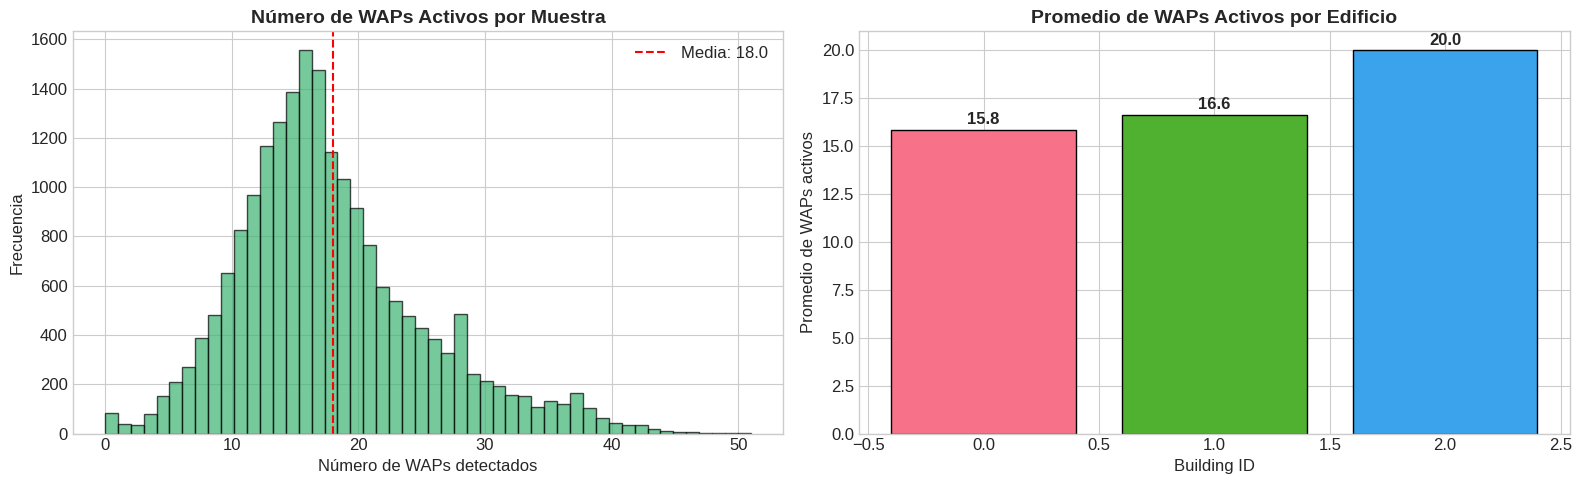

In [78]:
# ============================================================
# 3.5 WAPs ACTIVOS POR MUESTRA
# ============================================================
# Número de WAPs activos (con señal) por muestra
active_waps_per_sample = (wap_data != 100).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de WAPs activos por muestra
axes[0].hist(active_waps_per_sample, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0].set_title('Número de WAPs Activos por Muestra', fontweight='bold')
axes[0].set_xlabel('Número de WAPs detectados')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(x=active_waps_per_sample.mean(), color='red', linestyle='--',
                label=f'Media: {active_waps_per_sample.mean():.1f}')
axes[0].legend()

# WAPs activos por edificio
building_waps = df_train.groupby('BUILDINGID').apply(
    lambda x: (x[wap_cols] != 100).sum(axis=1).mean()
)
axes[1].bar(building_waps.index, building_waps.values,
            color=sns.color_palette("husl", 3), edgecolor='black')
axes[1].set_title('Promedio de WAPs Activos por Edificio', fontweight='bold')
axes[1].set_xlabel('Building ID')
axes[1].set_ylabel('Promedio de WAPs activos')
for i, v in enumerate(building_waps.values):
    axes[1].text(building_waps.index[i], v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Preprocesamiento de Datos
Se procesan las señales WiFi para prepararlas para el clustering:
1. **Reemplazo del valor 100** → El valor 100 indica "no detectado"; se reemplaza por un valor mínimo representativo (-105 dBm, umbral de sensibilidad típico).
2. **Eliminación de WAPs con varianza cero** → WAPs que nunca fueron detectados no aportan información.
3. **Estandarización** → Normalización de los datos para mejorar el rendimiento de los algoritmos de clustering.

In [79]:
# ============================================================
# 4. PREPROCESAMIENTO DE DATOS
# ============================================================

# 4.1 Reemplazar valor 100 por -105 (señal no detectada → mínimo de sensibilidad)
X_wap = df_train[wap_cols].copy()
X_wap.replace(100, -105, inplace=True)

# 4.2 Eliminar WAPs con varianza cero (sin información)
variance = X_wap.var()
zero_var_waps = variance[variance == 0].index.tolist()
X_wap = X_wap.drop(columns=zero_var_waps)

print(f"📡 WAPs originales:          {len(wap_cols)}")
print(f"📡 WAPs con varianza cero:   {len(zero_var_waps)}")
print(f"📡 WAPs conservados:         {X_wap.shape[1]}")

# 4.3 Guardar etiquetas reales para evaluación externa
y_building = df_train['BUILDINGID'].values
y_floor = df_train['FLOOR'].values

# Crear etiqueta combinada Building-Floor
y_building_floor = y_building * 10 + y_floor
label_names_bf = {b*10+f: f"B{b}-F{f}" for b in range(3) for f in range(5)}
print(f"\n🏷️  Clases Building-Floor únicas: {len(np.unique(y_building_floor))}")
print(f"   Etiquetas: {[label_names_bf[l] for l in sorted(np.unique(y_building_floor))]}")

# 4.4 Estandarización con StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wap)

print(f"\n✅ Datos estandarizados: {X_scaled.shape}")
print(f"   Media ≈ {X_scaled.mean():.4f}, Std ≈ {X_scaled.std():.4f}")

📡 WAPs originales:          520
📡 WAPs con varianza cero:   55
📡 WAPs conservados:         465

🏷️  Clases Building-Floor únicas: 13
   Etiquetas: ['B0-F0', 'B0-F1', 'B0-F2', 'B0-F3', 'B1-F0', 'B1-F1', 'B1-F2', 'B1-F3', 'B2-F0', 'B2-F1', 'B2-F2', 'B2-F3', 'B2-F4']

✅ Datos estandarizados: (19937, 465)
   Media ≈ -0.0000, Std ≈ 1.0000


## 5. Reducción de Dimensionalidad
Se utilizan **PCA** (Principal Component Analysis) y **t-SNE** (t-distributed Stochastic Neighbor Embedding) para proyectar los datos de alta dimensionalidad al espacio 2D y así poder visualizar la estructura inherente del dataset.

- **PCA**: Proyección lineal que preserva la máxima varianza.
- **t-SNE**: Proyección no lineal que preserva la estructura local de los datos.

⚠️ 90% de varianza no alcanzado con 200 componentes (máx: 89.35%)
⚠️ 95% de varianza no alcanzado con 200 componentes (máx: 89.35%)


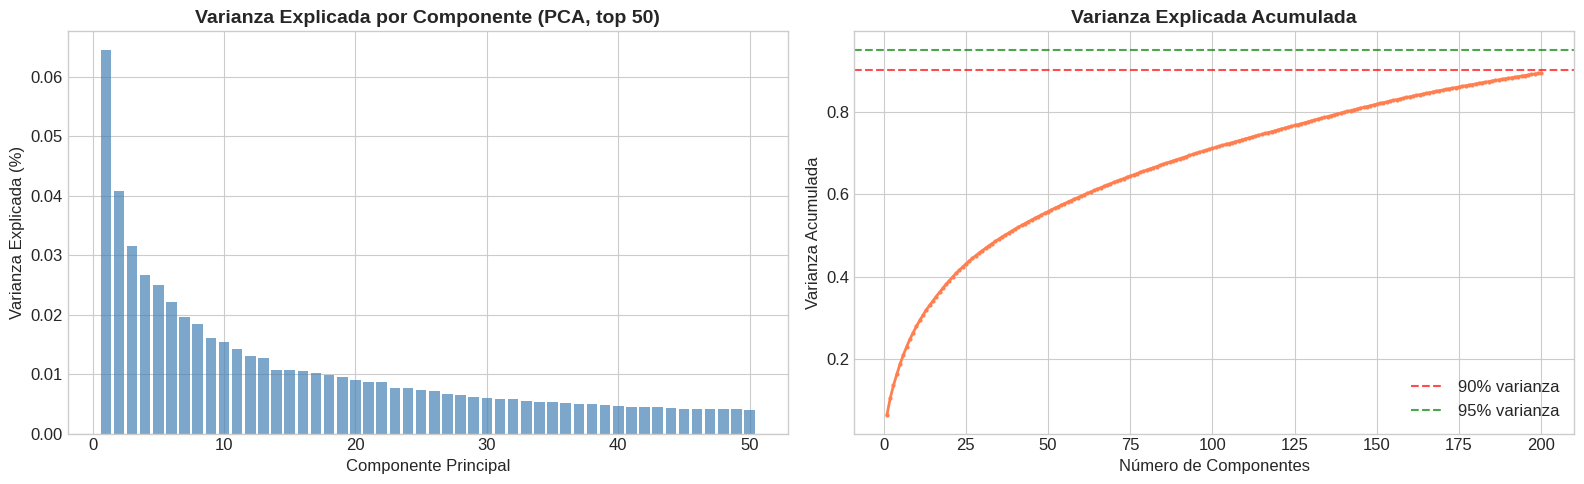

📊 Componentes para 90% de varianza: 200
📊 Componentes para 95% de varianza: 200
📊 Varianza explicada con 2 componentes:   10.52%
📊 Varianza explicada con 50 componentes:  55.79%
📊 Varianza explicada con 100 componentes: 71.09%
📊 Varianza explicada con 200 componentes: 89.35%


In [80]:
# ============================================================
# 5.1 PCA — ANÁLISIS DE COMPONENTES PRINCIPALES
# ============================================================

# PCA con suficientes componentes para analizar varianza explicada
# Con StandardScaler, la varianza se distribuye uniformemente entre features,
# por lo que se necesitan más componentes para capturar un alto % de varianza.
n_pca_analysis = min(200, X_scaled.shape[1])
pca_full = PCA(n_components=n_pca_analysis, random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

# Varianza explicada acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Varianza explicada por componente (mostrar primeros 50)
axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='steelblue', alpha=0.7)
axes[0].set_title('Varianza Explicada por Componente (PCA, top 50)', fontweight='bold')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')

# Varianza acumulada (todos los componentes analizados)
axes[1].plot(range(1, n_pca_analysis + 1), cumulative_variance, 'o-', color='coral',
             linewidth=2, markersize=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90% varianza')
axes[1].axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95% varianza')

# Calcular n_90 y n_95 con manejo correcto de edge cases
if np.any(cumulative_variance >= 0.90):
    n_90 = np.argmax(cumulative_variance >= 0.90) + 1
    axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.5)
else:
    n_90 = n_pca_analysis  # No se alcanza con los componentes analizados
    print(f"⚠️ 90% de varianza no alcanzado con {n_pca_analysis} componentes (máx: {cumulative_variance[-1]:.2%})")

if np.any(cumulative_variance >= 0.95):
    n_95 = np.argmax(cumulative_variance >= 0.95) + 1
    axes[1].axvline(x=n_95, color='green', linestyle=':', alpha=0.5)
else:
    n_95 = n_pca_analysis
    print(f"⚠️ 95% de varianza no alcanzado con {n_pca_analysis} componentes (máx: {cumulative_variance[-1]:.2%})")

axes[1].set_title('Varianza Explicada Acumulada', fontweight='bold')
axes[1].set_xlabel('Número de Componentes')
axes[1].set_ylabel('Varianza Acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"📊 Componentes para 90% de varianza: {n_90}")
print(f"📊 Componentes para 95% de varianza: {n_95}")
print(f"📊 Varianza explicada con 2 componentes:   {cumulative_variance[1]:.2%}")
print(f"📊 Varianza explicada con 50 componentes:  {cumulative_variance[49]:.2%}")
print(f"📊 Varianza explicada con 100 componentes: {cumulative_variance[99]:.2%}")
print(f"📊 Varianza explicada con 200 componentes: {cumulative_variance[-1]:.2%}")

# Guardar también las primeras 50 componentes para t-SNE
X_pca_50 = X_pca_full[:, :50]

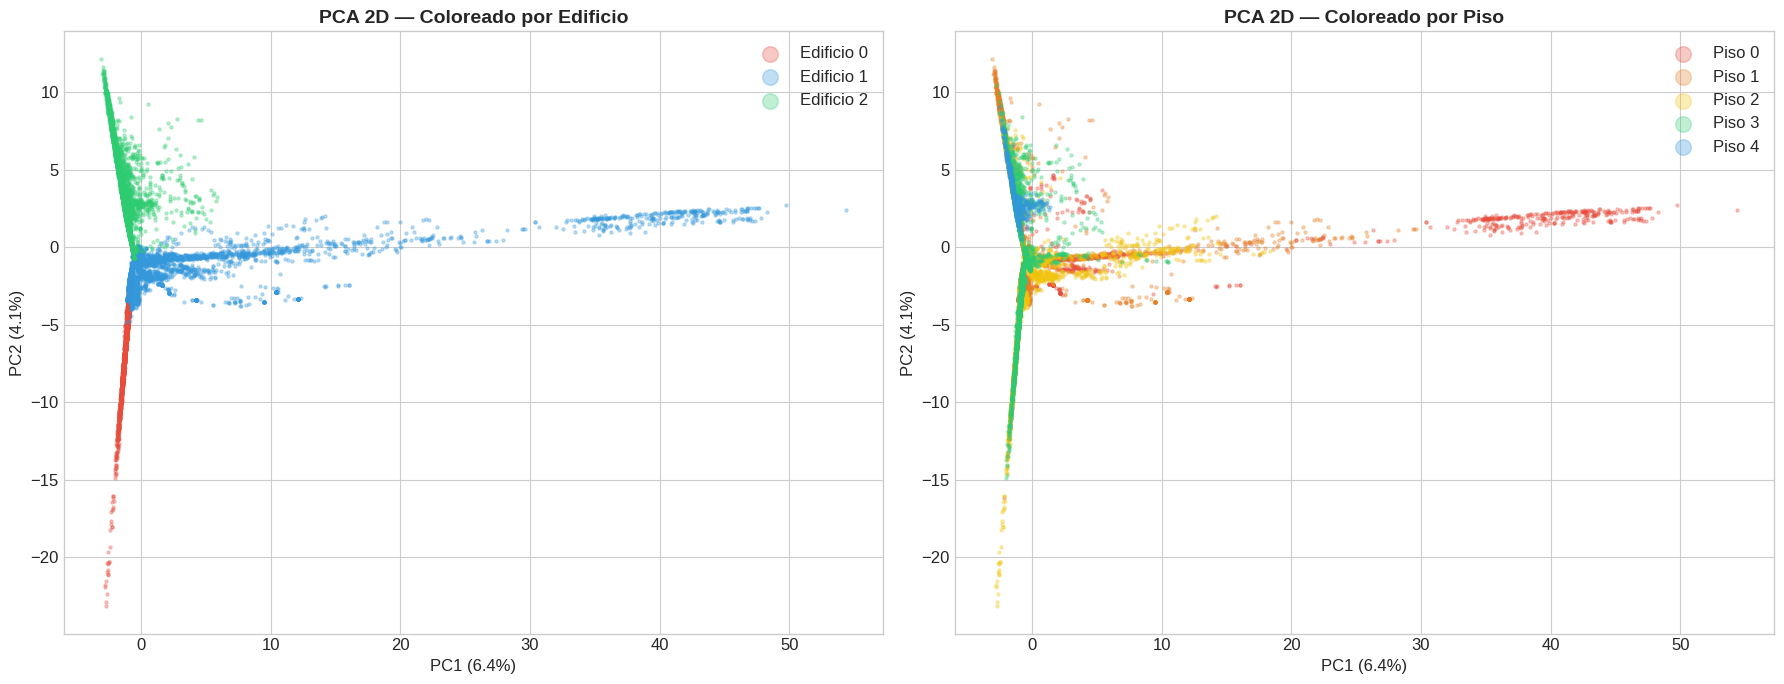

In [81]:
# ============================================================
# 5.2 VISUALIZACIÓN PCA 2D
# ============================================================

# Proyección a 2 componentes principales
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
colors_building = ['#e74c3c', '#3498db', '#2ecc71']
colors_floor = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

# Colorear por edificio
for b in sorted(np.unique(y_building)):
    mask = y_building == b
    # Verificar si el índice de color es válido
    if 0 <= b < len(colors_building):
        color = colors_building[b]
    else:
        color = 'gray' # Color por defecto si el índice está fuera de rango
        
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=f'Edificio {b}',
                    alpha=0.3, s=5)
axes[0].set_title('PCA 2D — Coloreado por Edificio', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].legend(markerscale=5)

# Colorear por piso
for f in sorted(np.unique(y_floor)):
    mask = y_floor == f
    # Verificar si el índice de color es válido
    if 0 <= f < len(colors_floor):
        color = colors_floor[f]
    else:
        color = 'gray' # Color por defecto
        
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=color, label=f'Piso {f}',
                    alpha=0.3, s=5)
axes[1].set_title('PCA 2D — Coloreado por Piso', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[1].legend(markerscale=5)

plt.tight_layout()
plt.show()

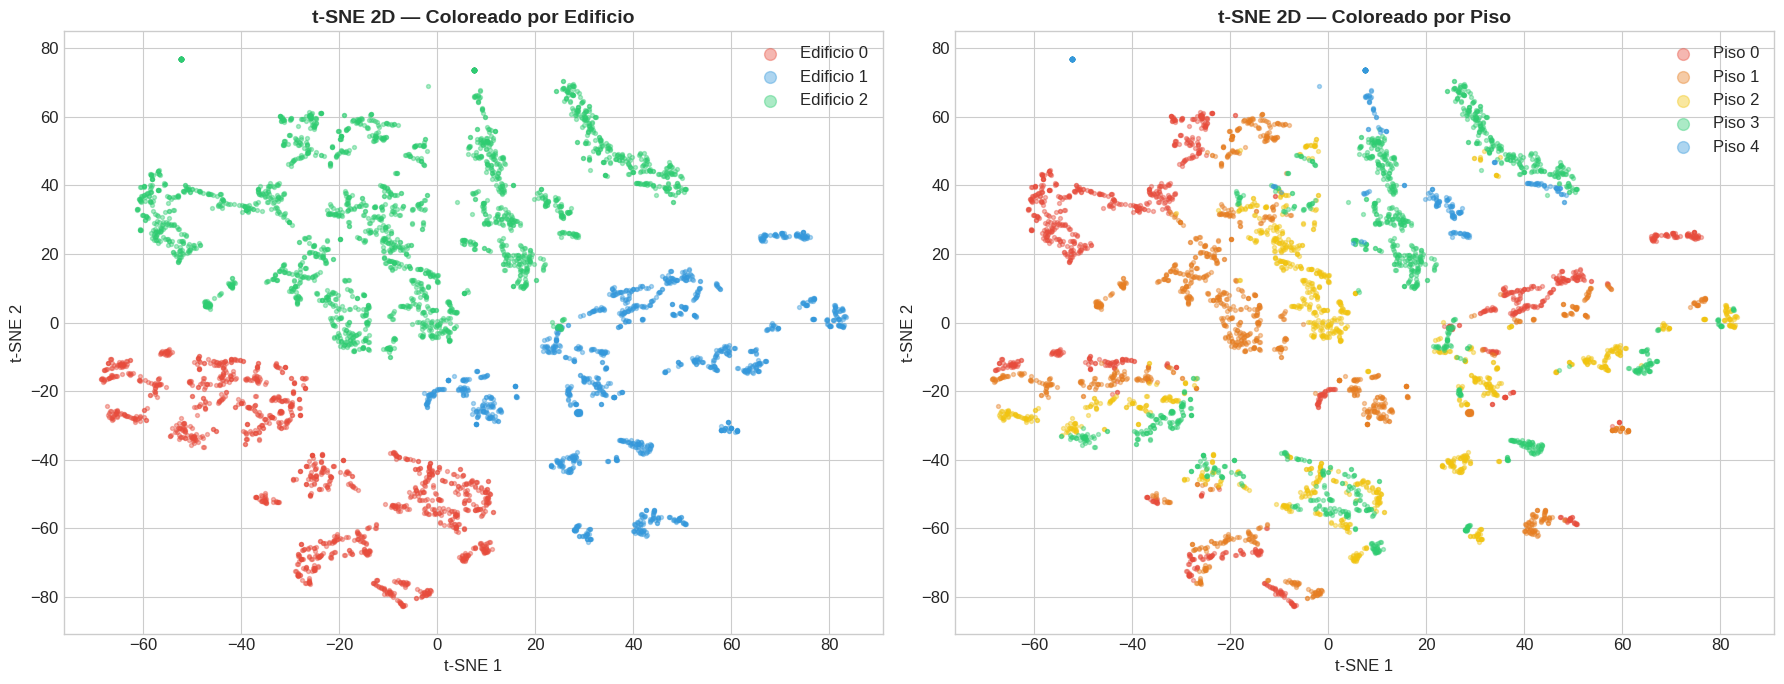

✅ t-SNE completado sobre 5000 muestras (submuestra para eficiencia)


In [82]:
# ============================================================
# 5.3 t-SNE — VISUALIZACIÓN NO LINEAL
# ============================================================

# Usamos PCA previo para reducir a 50 dims (acelera t-SNE) si existe, sino generamos on-the-fly
if 'X_pca_50' not in locals():
    print("⚠️ X_pca_50 no encontrado, calculando PCA(n_components=50) para acelerar t-SNE...")
    from sklearn.decomposition import PCA
    X_input_tsne = PCA(n_components=50).fit_transform(X_scaled)
else:
    X_input_tsne = X_pca_50

# Submuestra para eficiencia computacional
np.random.seed(42)
n_sample = min(5000, len(X_input_tsne))
# idx_sample debe ser un array de enteros para indexar numpy arrays
idx_sample = np.random.choice(len(X_input_tsne), n_sample, replace=False)

X_sample_pca = X_input_tsne[idx_sample]

# Corregido: acceso a numpy array con indices directos, no .iloc
# Aseguramos que y_building y y_floor sean arrays de numpy antes de indexar
if not isinstance(y_building, np.ndarray):
    y_building_sample = y_building.values[idx_sample]
else:
    y_building_sample = y_building[idx_sample]

if not isinstance(y_floor, np.ndarray):
    y_floor_sample = y_floor.values[idx_sample]
else:
    y_floor_sample = y_floor[idx_sample]

# t-SNE con 2 componentes
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate='auto')
X_tsne_2d = tsne.fit_transform(X_sample_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors_building = ['#e74c3c', '#3498db', '#2ecc71']
colors_floor = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']

# Colorear por edificio
unique_buildings = np.unique(y_building_sample)
for b in sorted(unique_buildings):
    mask = y_building_sample == b
    
    # Color seguro
    if 0 <= b < len(colors_building):
        color = colors_building[b]
    else:
        color = 'gray'

    axes[0].scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                    c=color, label=f'Edificio {b}',
                    alpha=0.4, s=8)
axes[0].set_title('t-SNE 2D — Coloreado por Edificio', fontweight='bold')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=3)

# Colorear por piso
unique_floors = np.unique(y_floor_sample)
for f in sorted(unique_floors):
    mask = y_floor_sample == f
    
    # Color seguro
    if 0 <= f < len(colors_floor):
        color = colors_floor[f]
    else:
        color = 'gray'

    axes[1].scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                    c=color, label=f'Piso {f}',
                    alpha=0.4, s=8)
axes[1].set_title('t-SNE 2D — Coloreado por Piso', fontweight='bold')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

print(f"✅ t-SNE completado sobre {n_sample} muestras (submuestra para eficiencia)")

## 6. Determinación del Número Óptimo de Clusters

Para seleccionar el número adecuado de clusters, empleamos tres métodos complementarios:

| Método | Descripción | Criterio |
|--------|-------------|----------|
| **Método del Codo (Elbow)** | Analiza la inercia (suma de distancias al cuadrado al centroide) vs. número de clusters | Buscar el "codo" donde la mejora marginal se reduce drásticamente |
| **Método de Silueta (Silhouette)** | Mide la cohesión y separación de los clusters | Maximizar el coeficiente de silueta promedio |
| **Calinski-Harabasz** | Ratio de dispersión entre clusters vs. dentro de clusters | Maximizar el índice |

> **Nota:** Utilizamos datos reducidos con PCA para mayor eficiencia computacional.

📊 Usando 50 componentes PCA para clustering
   Varianza explicada con 50 componentes: 55.79%

Evaluando K-Means para diferentes valores de K...
  K= 2 | Inercia=4,662,058 | Silueta=0.5690 | CH=2179.7
  K= 3 | Inercia=4,359,629 | Silueta=0.1095 | CH=1856.8
  K= 4 | Inercia=4,143,989 | Silueta=0.1365 | CH=1648.0
  K= 5 | Inercia=3,906,521 | Silueta=0.1698 | CH=1613.9
  K= 6 | Inercia=3,733,232 | Silueta=0.1950 | CH=1536.1
  K= 7 | Inercia=3,586,888 | Silueta=0.1964 | CH=1467.7
  K= 8 | Inercia=3,386,797 | Silueta=0.2115 | CH=1500.5
  K= 9 | Inercia=3,301,956 | Silueta=0.1493 | CH=1410.6
  K=10 | Inercia=3,156,132 | Silueta=0.1681 | CH=1414.0
  K=11 | Inercia=3,137,276 | Silueta=0.1305 | CH=1292.2
  K=12 | Inercia=2,987,439 | Silueta=0.1387 | CH=1324.4
  K=13 | Inercia=2,887,544 | Silueta=0.1911 | CH=1313.4
  K=14 | Inercia=2,808,873 | Silueta=0.1724 | CH=1289.2
  K=15 | Inercia=2,726,020 | Silueta=0.1900 | CH=1276.7


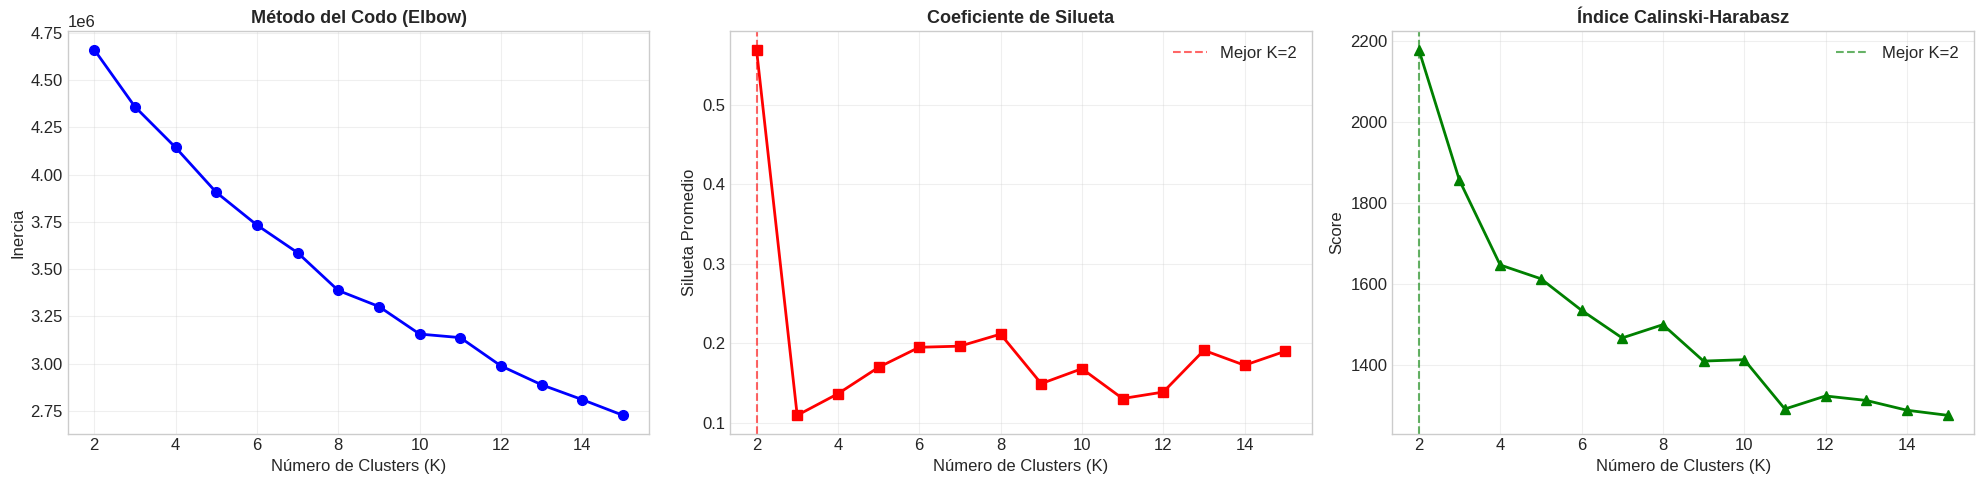


📊 RESUMEN — Número Óptimo de Clusters:
   Método Silueta:           K = 2
   Método Calinski-Harabasz: K = 2
   Nota: El dataset contiene 3 edificios × ~5 pisos = ~13 zonas lógicas


In [83]:
# ============================================================
# 6.1 SELECCIÓN ÓPTIMA DE K — TRES MÉTODOS
# ============================================================

# Usar PCA reducido para eficiencia
# Con StandardScaler, la varianza se distribuye uniformemente entre features,
# por lo que n_90 puede ser muy alto. Usamos un rango práctico de 30-50 componentes
# que captura suficiente estructura mientras mantiene eficiencia computacional.
n_components_opt = min(max(n_90, 30), 50)
print(f"📊 Usando {n_components_opt} componentes PCA para clustering")

pca_opt = PCA(n_components=n_components_opt, random_state=42)
X_pca_opt = pca_opt.fit_transform(X_scaled)
print(f"   Varianza explicada con {n_components_opt} componentes: {sum(pca_opt.explained_variance_ratio_):.2%}")

K_range = range(2, 16)
inertias = []
silhouette_scores = []
calinski_scores = []

print("\nEvaluando K-Means para diferentes valores de K...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_pca_opt)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca_opt, labels, sample_size=5000, random_state=42))
    calinski_scores.append(calinski_harabasz_score(X_pca_opt, labels))
    print(f"  K={k:2d} | Inercia={km.inertia_:,.0f} | Silueta={silhouette_scores[-1]:.4f} | CH={calinski_scores[-1]:.1f}")

# --- Gráficos ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Método del Codo
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Método del Codo (Elbow)', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

# Método de Silueta
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=7)
best_k_sil = list(K_range)[np.argmax(silhouette_scores)]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--', alpha=0.6,
                label=f'Mejor K={best_k_sil}')
axes[1].set_title('Coeficiente de Silueta', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silueta Promedio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz
axes[2].plot(K_range, calinski_scores, 'g^-', linewidth=2, markersize=7)
best_k_ch = list(K_range)[np.argmax(calinski_scores)]
axes[2].axvline(x=best_k_ch, color='green', linestyle='--', alpha=0.6,
                label=f'Mejor K={best_k_ch}')
axes[2].set_title('Índice Calinski-Harabasz', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Número de Clusters (K)')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 RESUMEN — Número Óptimo de Clusters:")
print(f"   Método Silueta:           K = {best_k_sil}")
print(f"   Método Calinski-Harabasz: K = {best_k_ch}")
print(f"   Nota: El dataset contiene 3 edificios × ~5 pisos = ~13 zonas lógicas")

## 7. Aplicación de Algoritmos de Clustering

Implementaremos cinco algoritmos de clustering para comparar sus enfoques y resultados:

| # | Algoritmo | Tipo | Parámetros Clave |
|---|-----------|------|------------------|
| 1 | **K-Means** | Basado en centroides | `n_clusters` |
| 2 | **DBSCAN** | Basado en densidad | `eps`, `min_samples` |
| 3 | **Agglomerative Clustering** | Jerárquico | `n_clusters`, `linkage` |
| 4 | **Mean Shift** | Basado en densidad | `bandwidth` (estimado automáticamente) |
| 5 | **Gaussian Mixture Model (GMM)** | Basado en distribución | `n_components`, `covariance_type` |

> **Datos utilizados:** Usaremos `X_pca_opt` (PCA reducido) para todos los algoritmos, asegurando comparabilidad y eficiencia.

🔵 K-Means con K=3 (Silueta sugirió K=2, CH sugirió K=2)


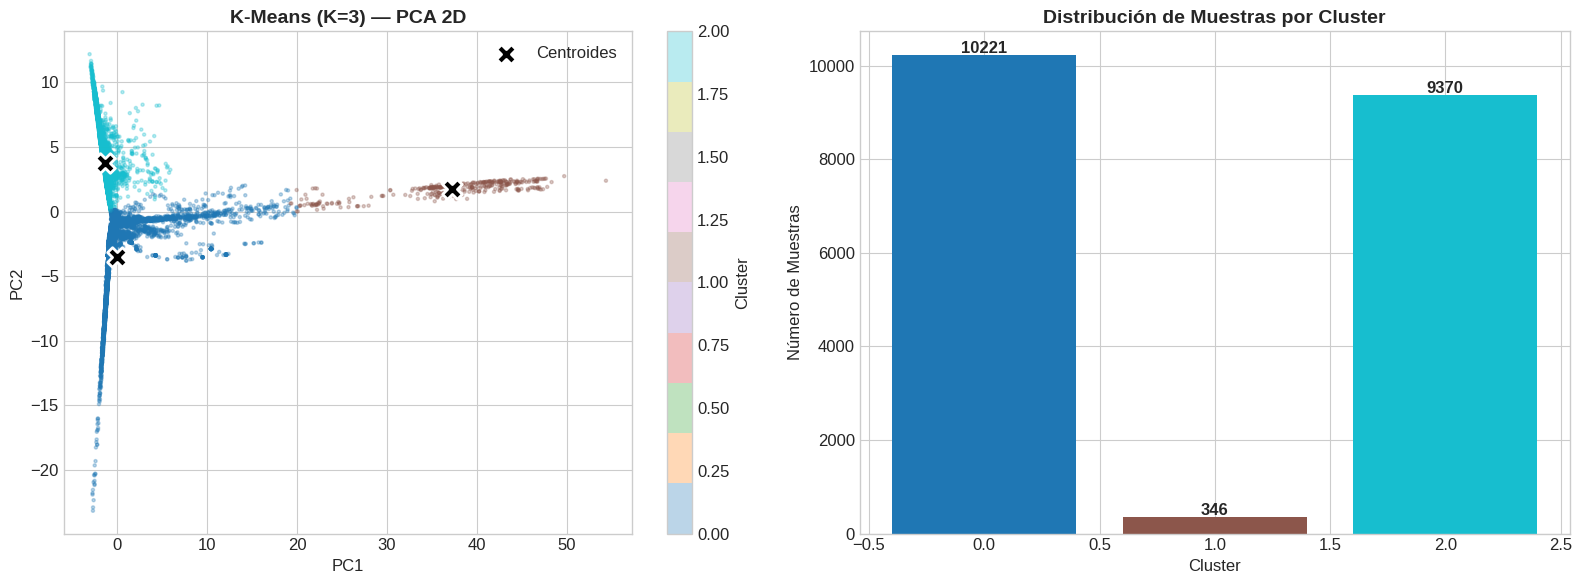

📊 Clusters formados: 3
📊 Inercia: 4,359,629
📊 Tamaños: {0: np.int64(10221), 1: np.int64(346), 2: np.int64(9370)}


In [84]:
# ============================================================
# 7.1 K-MEANS CLUSTERING
# ============================================================

# Usar K basado en los métodos de evaluación
# Se aplica un mínimo de K=3 (conocimiento del dominio: 3 edificios)
k_optimal = max(best_k_sil, 3)
print(f"🔵 K-Means con K={k_optimal} (Silueta sugirió K={best_k_sil}, CH sugirió K={best_k_ch})")

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10, max_iter=300)
labels_kmeans = kmeans.fit_predict(X_pca_opt)

# Visualización en PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=labels_kmeans, cmap='tab10', alpha=0.3, s=5)
# Centroides en PCA 2D
centroids_2d = pca_2d.transform(pca_opt.inverse_transform(kmeans.cluster_centers_))
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                c='black', marker='X', s=200, edgecolors='white', linewidths=2,
                zorder=5, label='Centroides')
axes[0].set_title(f'K-Means (K={k_optimal}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Distribución de clusters
cluster_counts = pd.Series(labels_kmeans).value_counts().sort_index()
axes[1].bar(cluster_counts.index, cluster_counts.values, color=plt.cm.tab10(np.linspace(0, 1, k_optimal)))
axes[1].set_title('Distribución de Muestras por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Muestras')
for i, v in enumerate(cluster_counts.values):
    axes[1].text(cluster_counts.index[i], v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📊 Clusters formados: {k_optimal}")
print(f"📊 Inercia: {kmeans.inertia_:,.0f}")
print(f"📊 Tamaños: {dict(cluster_counts)}")

📊 Usando min_samples = 20 (2 × 50 dimensiones, cap en [5,20])


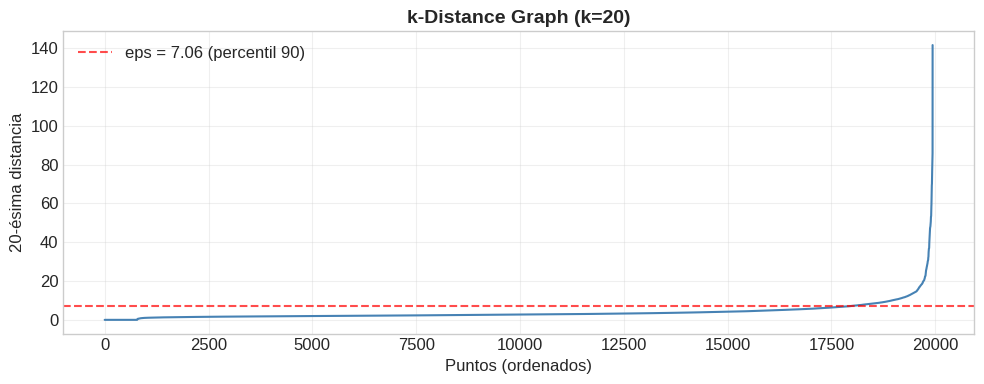

📊 eps estimado (percentil 90): 7.06


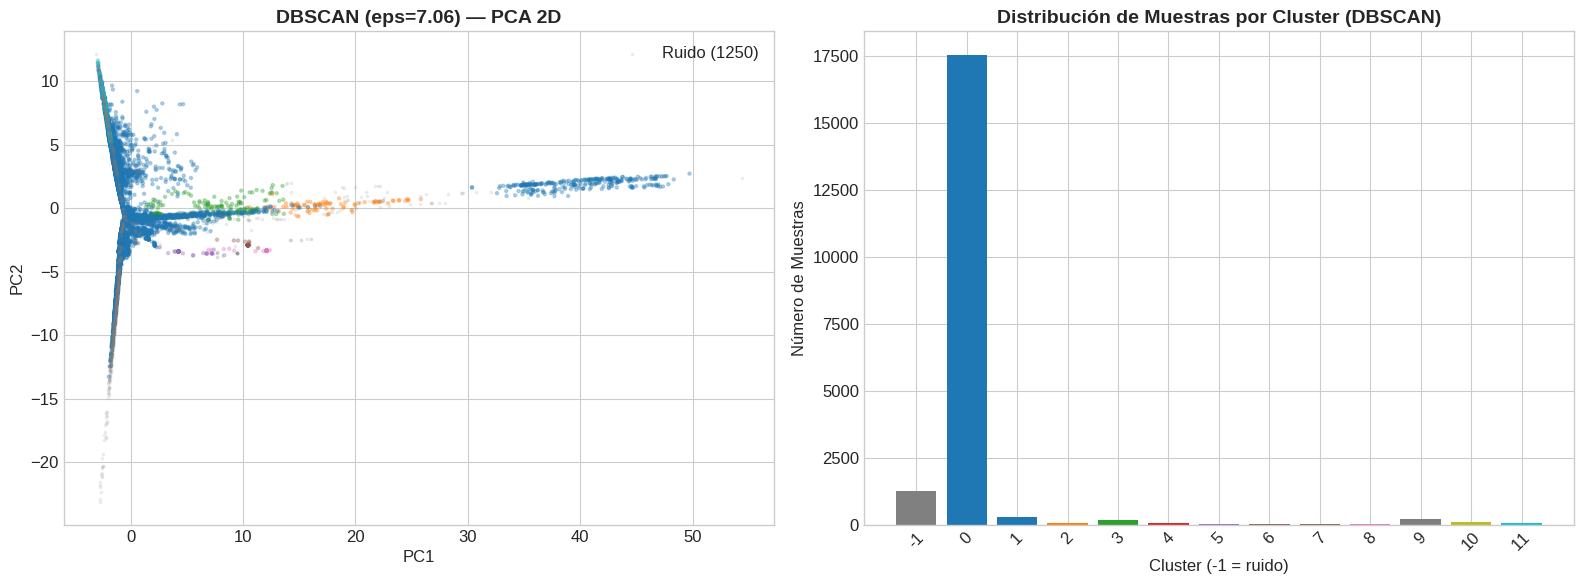

📊 Clusters encontrados: 12
📊 Puntos de ruido: 1250 (6.3%)


In [85]:
# ============================================================
# 7.2 DBSCAN — DENSITY-BASED SPATIAL CLUSTERING
# ============================================================

from sklearn.neighbors import NearestNeighbors

# Estimar eps usando k-distance graph
# Heurística: min_samples = 2 * dimensiones, pero limitado a un rango práctico
k_neighbors = min(2 * X_pca_opt.shape[1], 20)
k_neighbors = max(k_neighbors, 5)  # mínimo 5 vecinos
print(f"📊 Usando min_samples = {k_neighbors} (2 × {X_pca_opt.shape[1]} dimensiones, cap en [5,20])")

nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_pca_opt)
distances, _ = nn.kneighbors(X_pca_opt)
k_distances = np.sort(distances[:, -1])

# Gráfico k-distance
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(k_distances, linewidth=1.5, color='steelblue')
ax.set_title(f'k-Distance Graph (k={k_neighbors})', fontweight='bold')
ax.set_xlabel('Puntos (ordenados)')
ax.set_ylabel(f'{k_neighbors}-ésima distancia')
ax.grid(True, alpha=0.3)

# Marcar el percentil elegido
eps_percentile = 90
eps_value = np.percentile(k_distances, eps_percentile)
ax.axhline(y=eps_value, color='red', linestyle='--', alpha=0.7,
           label=f'eps = {eps_value:.2f} (percentil {eps_percentile})')
ax.legend()

plt.tight_layout()
plt.show()

# Asegurar eps razonable (no cero ni demasiado grande)
if eps_value < 0.01:
    # Fallback: usar la mediana de las k-distancias del 90-99 percentil
    eps_value = np.percentile(k_distances, 97)
    print(f"⚠️ eps recalculado (percentil 97): {eps_value:.2f}")
else:
    print(f"📊 eps estimado (percentil {eps_percentile}): {eps_value:.2f}")

# Aplicar DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=k_neighbors)
labels_dbscan = dbscan.fit_predict(X_pca_opt)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = (labels_dbscan == -1).sum()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters + ruido
mask_noise = labels_dbscan == -1
mask_cluster = ~mask_noise
scatter2 = axes[0].scatter(X_pca_2d[mask_cluster, 0], X_pca_2d[mask_cluster, 1],
                           c=labels_dbscan[mask_cluster], cmap='tab10', alpha=0.3, s=5)
axes[0].scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1],
                c='gray', alpha=0.1, s=3, label=f'Ruido ({n_noise})')
axes[0].set_title(f'DBSCAN (eps={eps_value:.2f}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Distribución (mostrar top clusters si hay muchos)
cluster_counts_db = pd.Series(labels_dbscan).value_counts().sort_index()
if len(cluster_counts_db) > 20:
    # Mostrar ruido + top clusters
    top_n = 15
    top_labels = cluster_counts_db.drop(-1, errors='ignore').nlargest(top_n)
    if -1 in cluster_counts_db.index:
        plot_counts = pd.concat([pd.Series({-1: cluster_counts_db[-1]}), top_labels])
    else:
        plot_counts = top_labels
    colors_db = ['gray' if idx == -1 else plt.cm.tab10(i / max(top_n, 1))
                 for i, idx in enumerate(plot_counts.index)]
    axes[1].bar(plot_counts.index.astype(str), plot_counts.values, color=colors_db)
    axes[1].set_title(f'Top {top_n} Clusters + Ruido (de {n_clusters_db} total)', fontweight='bold')
else:
    colors_db = ['gray' if idx == -1 else plt.cm.tab10(idx / max(n_clusters_db, 1))
                 for idx in cluster_counts_db.index]
    axes[1].bar(cluster_counts_db.index.astype(str), cluster_counts_db.values, color=colors_db)
    axes[1].set_title('Distribución de Muestras por Cluster (DBSCAN)', fontweight='bold')
axes[1].set_xlabel('Cluster (-1 = ruido)')
axes[1].set_ylabel('Número de Muestras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"📊 Clusters encontrados: {n_clusters_db}")
print(f"📊 Puntos de ruido: {n_noise} ({n_noise/len(labels_dbscan)*100:.1f}%)")

🟢 Agglomerative Clustering con n_clusters=3, linkage='ward'


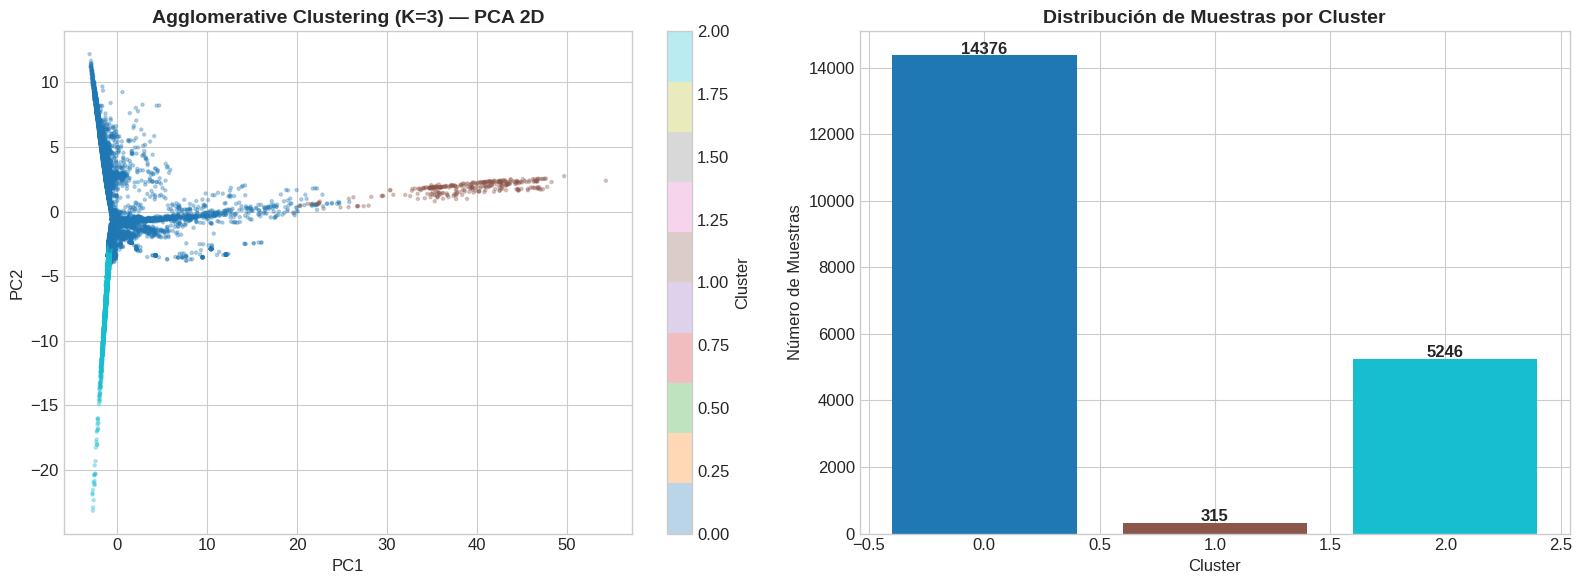

📊 Tamaños: {0: np.int64(14376), 1: np.int64(315), 2: np.int64(5246)}


In [86]:
# ============================================================
# 7.3 AGGLOMERATIVE CLUSTERING (JERÁRQUICO)
# ============================================================

print(f"🟢 Agglomerative Clustering con n_clusters={k_optimal}, linkage='ward'")

agg = AgglomerativeClustering(n_clusters=k_optimal, linkage='ward')
labels_agg = agg.fit_predict(X_pca_opt)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter3 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=labels_agg, cmap='tab10', alpha=0.3, s=5)
axes[0].set_title(f'Agglomerative Clustering (K={k_optimal}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[0], label='Cluster')

# Distribución
cluster_counts_agg = pd.Series(labels_agg).value_counts().sort_index()
axes[1].bar(cluster_counts_agg.index, cluster_counts_agg.values,
            color=plt.cm.tab10(np.linspace(0, 1, k_optimal)))
axes[1].set_title('Distribución de Muestras por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Muestras')
for i, v in enumerate(cluster_counts_agg.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"📊 Tamaños: {dict(cluster_counts_agg)}")

🟡 Mean Shift con bandwidth estimado = 15.33


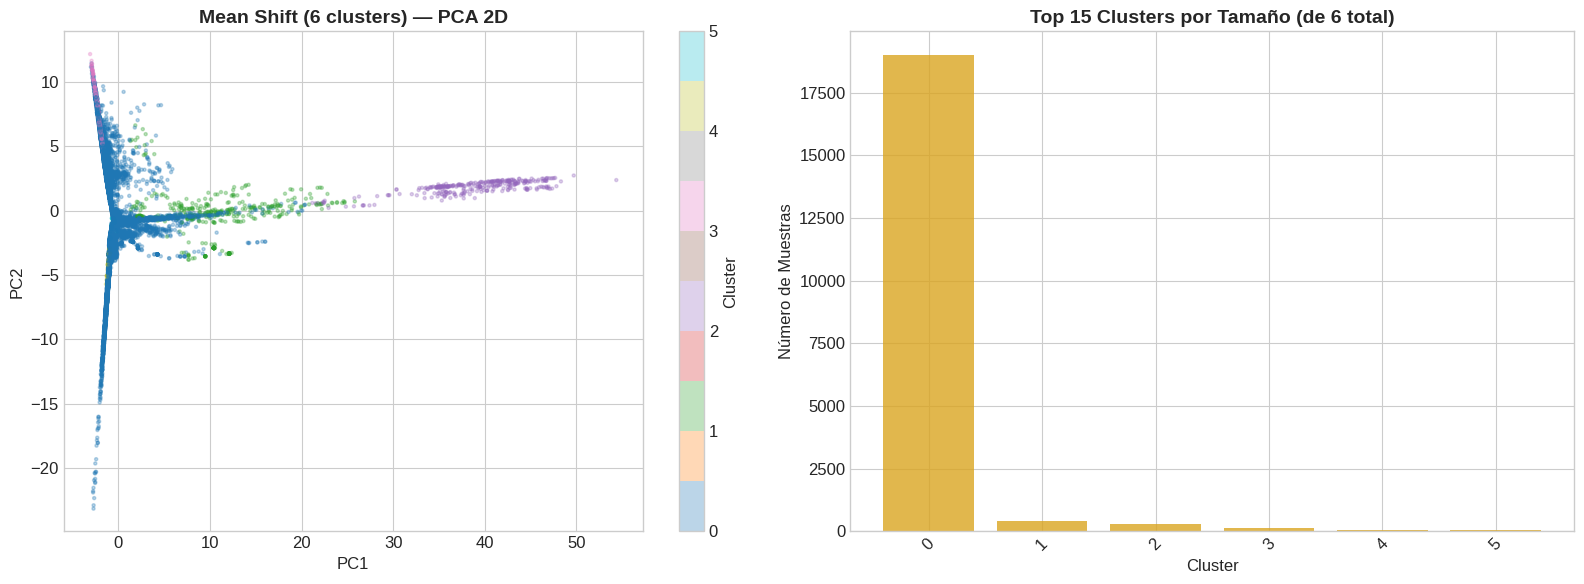

📊 Clusters encontrados: 6
📊 Bandwidth: 15.33


In [87]:
# ============================================================
# 7.4 MEAN SHIFT CLUSTERING
# ============================================================

from sklearn.cluster import estimate_bandwidth

# Submuestra para Mean Shift (computacionalmente costoso)
np.random.seed(42)
n_ms = min(5000, len(X_pca_opt))
idx_ms = np.random.choice(len(X_pca_opt), n_ms, replace=False)
X_ms = X_pca_opt[idx_ms]

# Estimar bandwidth automáticamente
bandwidth = estimate_bandwidth(X_ms, quantile=0.15, random_state=42)
print(f"🟡 Mean Shift con bandwidth estimado = {bandwidth:.2f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms_sub = ms.fit_predict(X_ms)

# Asignar etiquetas al dataset completo usando predict
labels_ms = ms.predict(X_pca_opt)

n_clusters_ms = len(np.unique(labels_ms))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter4 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=labels_ms, cmap='tab10', alpha=0.3, s=5)
axes[0].set_title(f'Mean Shift ({n_clusters_ms} clusters) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter4, ax=axes[0], label='Cluster')

# Distribución
cluster_counts_ms = pd.Series(labels_ms).value_counts().sort_index()
top_clusters = cluster_counts_ms.head(15)  # mostrar solo top 15
axes[1].bar(top_clusters.index.astype(str), top_clusters.values, color='goldenrod', alpha=0.8)
axes[1].set_title(f'Top 15 Clusters por Tamaño (de {n_clusters_ms} total)', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Muestras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"📊 Clusters encontrados: {n_clusters_ms}")
print(f"📊 Bandwidth: {bandwidth:.2f}")

🟣 GMM con n_components=3, covariance_type='full'


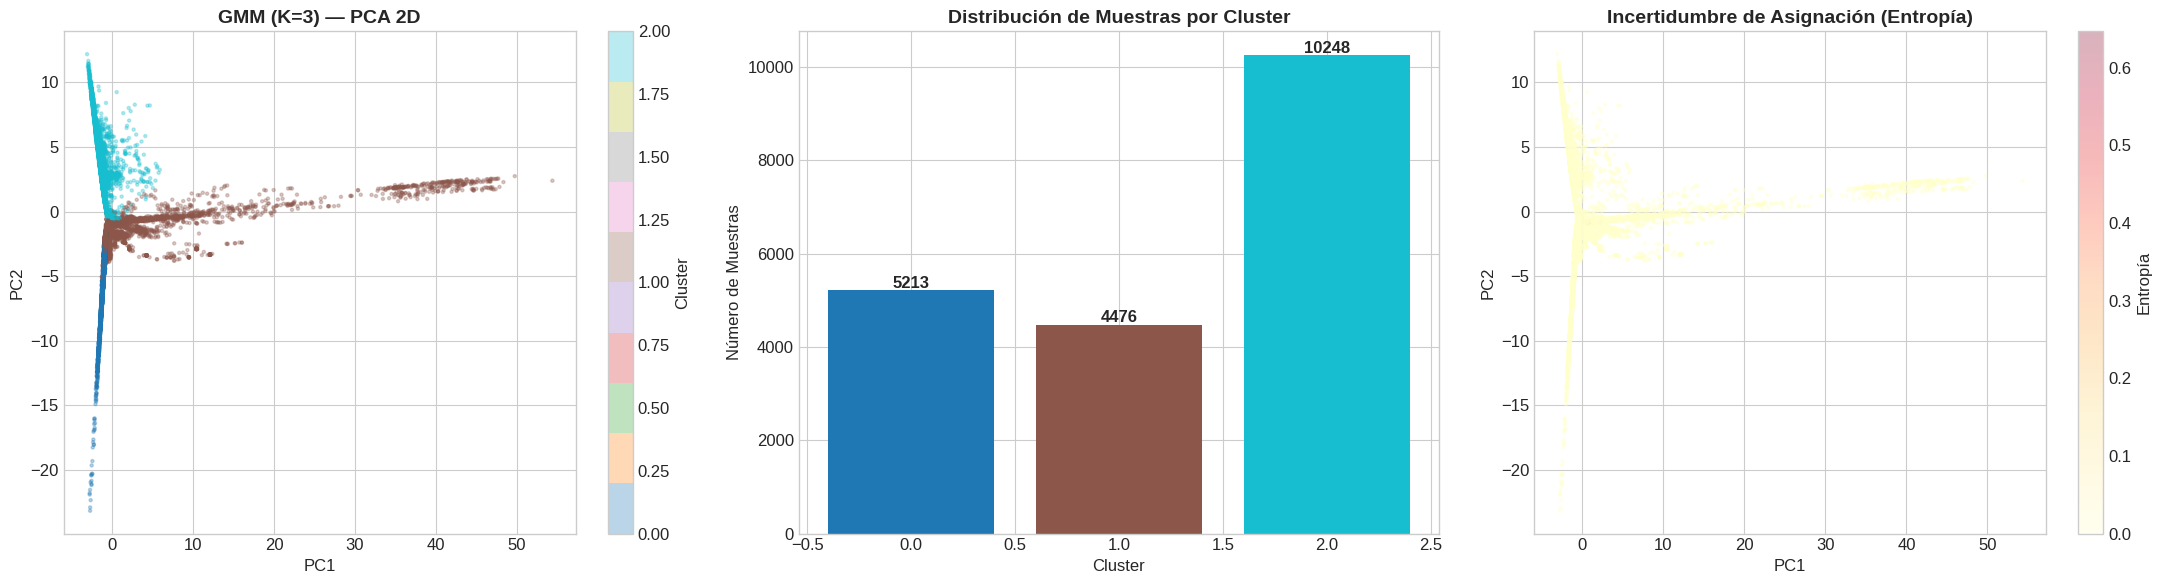

📊 BIC: -1,320,812
📊 AIC: -1,352,231
📊 Log-likelihood: 34.1121
📊 Tamaños: {0: np.int64(5213), 1: np.int64(4476), 2: np.int64(10248)}


In [88]:
# ============================================================
# 7.5 GAUSSIAN MIXTURE MODEL (GMM)
# ============================================================

print(f"🟣 GMM con n_components={k_optimal}, covariance_type='full'")

gmm = GaussianMixture(n_components=k_optimal, covariance_type='full',
                       random_state=42, n_init=5, max_iter=200)
labels_gmm = gmm.fit_predict(X_pca_opt)
probs_gmm = gmm.predict_proba(X_pca_opt)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Clusters
scatter5 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=labels_gmm, cmap='tab10', alpha=0.3, s=5)
axes[0].set_title(f'GMM (K={k_optimal}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter5, ax=axes[0], label='Cluster')

# Distribución
cluster_counts_gmm = pd.Series(labels_gmm).value_counts().sort_index()
axes[1].bar(cluster_counts_gmm.index, cluster_counts_gmm.values,
            color=plt.cm.tab10(np.linspace(0, 1, k_optimal)))
axes[1].set_title('Distribución de Muestras por Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Número de Muestras')
for i, v in enumerate(cluster_counts_gmm.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Incertidumbre (entropía de probabilidades)
entropy = -np.sum(probs_gmm * np.log(probs_gmm + 1e-10), axis=1)
scatter_ent = axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=entropy, cmap='YlOrRd', alpha=0.3, s=5)
axes[2].set_title('Incertidumbre de Asignación (Entropía)', fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
plt.colorbar(scatter_ent, ax=axes[2], label='Entropía')

plt.tight_layout()
plt.show()

print(f"📊 BIC: {gmm.bic(X_pca_opt):,.0f}")
print(f"📊 AIC: {gmm.aic(X_pca_opt):,.0f}")
print(f"📊 Log-likelihood: {gmm.score(X_pca_opt):.4f}")
print(f"📊 Tamaños: {dict(cluster_counts_gmm)}")

## 8. Evaluación Interna de Clustering

Las métricas internas evalúan la calidad del clustering **sin usar etiquetas reales** (ground truth). Miden la cohesión intra-cluster y la separación inter-cluster.

| Métrica | Rango | Óptimo | Interpretación |
|---------|-------|--------|----------------|
| **Silhouette Score** | [-1, 1] | Máximo → 1 | Mide qué tan similar es un punto a su propio cluster vs. otros clusters |
| **Davies-Bouldin Index** | [0, ∞) | Mínimo → 0 | Ratio promedio de dispersión dentro del cluster vs. distancia entre centroides |
| **Dunn Index** | [0, ∞) | Máximo → ∞ | Ratio entre mínima distancia inter-cluster y máxima distancia intra-cluster |

> **Nota:** DBSCAN se evalúa excluyendo los puntos de ruido (label = -1).

In [89]:
# ============================================================
# 8.1 CÁLCULO DE MÉTRICAS INTERNAS
# ============================================================

from scipy.spatial.distance import cdist

def dunn_index(X, labels, sample_size=3000):
    """Calcula el índice de Dunn (versión eficiente con submuestra)."""
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0

    # Submuestra para eficiencia
    if len(X) > sample_size:
        np.random.seed(42)
        idx = np.random.choice(len(X), sample_size, replace=False)
        X = X[idx]
        labels = labels[idx]
        unique_labels = np.unique(labels)

    # Máxima distancia intra-cluster
    max_intra = 0
    centroids = []
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            dists = cdist(cluster_points, cluster_points)
            max_intra = max(max_intra, np.max(dists))
        centroids.append(cluster_points.mean(axis=0))

    if max_intra == 0:
        return 0.0

    # Mínima distancia inter-cluster (entre centroides)
    centroids = np.array(centroids)
    inter_dists = cdist(centroids, centroids)
    np.fill_diagonal(inter_dists, np.inf)
    min_inter = np.min(inter_dists)

    return min_inter / max_intra

# Diccionario para almacenar resultados
all_labels = {
    'K-Means': labels_kmeans,
    'DBSCAN': labels_dbscan,
    'Agglomerative': labels_agg,
    'Mean Shift': labels_ms,
    'GMM': labels_gmm
}

internal_results = {}

for name, labels in all_labels.items():
    # Para DBSCAN, filtrar ruido
    if -1 in labels:
        mask = labels != -1
        X_eval = X_pca_opt[mask]
        labels_eval = labels[mask]
        n_clusters = len(set(labels_eval))
    else:
        X_eval = X_pca_opt
        labels_eval = labels
        n_clusters = len(set(labels_eval))

    if n_clusters < 2:
        internal_results[name] = {
            'n_clusters': n_clusters,
            'silhouette': np.nan,
            'davies_bouldin': np.nan,
            'dunn': np.nan
        }
        continue

    sil = silhouette_score(X_eval, labels_eval, sample_size=5000, random_state=42)
    db = davies_bouldin_score(X_eval, labels_eval)
    dunn = dunn_index(X_eval, labels_eval)

    internal_results[name] = {
        'n_clusters': n_clusters,
        'silhouette': sil,
        'davies_bouldin': db,
        'dunn': dunn
    }

# Tabla de resultados
df_internal = pd.DataFrame(internal_results).T
df_internal.columns = ['N° Clusters', 'Silhouette ↑', 'Davies-Bouldin ↓', 'Dunn Index ↑']
df_internal.index.name = 'Algoritmo'

print("=" * 70)
print("       EVALUACIÓN INTERNA DE CLUSTERING")
print("=" * 70)
print(df_internal.to_string(float_format=lambda x: f'{x:.4f}'))
print("=" * 70)
print("\n↑ = Mayor es mejor  |  ↓ = Menor es mejor")

       EVALUACIÓN INTERNA DE CLUSTERING
               N° Clusters  Silhouette ↑  Davies-Bouldin ↓  Dunn Index ↑
Algoritmo                                                               
K-Means             3.0000        0.1095            2.4025        0.0647
DBSCAN             12.0000        0.0377            0.7386        0.2444
Agglomerative       3.0000        0.1399            2.2674        0.0704
Mean Shift          6.0000        0.3273            1.0614        0.1920
GMM                 3.0000        0.1200            3.0386        0.0798

↑ = Mayor es mejor  |  ↓ = Menor es mejor


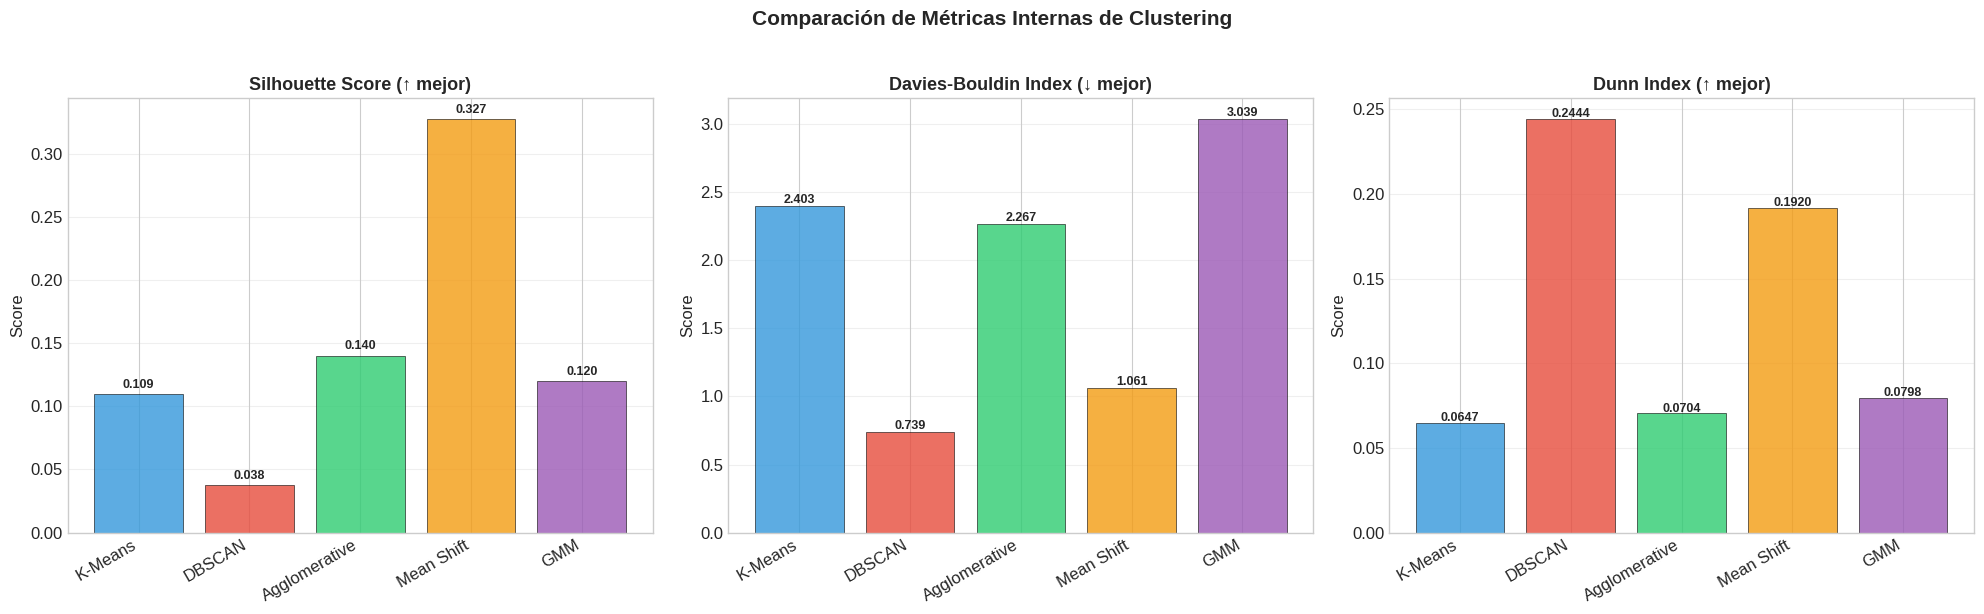

In [90]:
# ============================================================
# 8.2 VISUALIZACIÓN MÉTRICAS INTERNAS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
algorithms = df_internal.index.tolist()
x_pos = np.arange(len(algorithms))
colors_alg = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Silhouette Score (mayor = mejor)
vals_sil = df_internal['Silhouette ↑'].values
axes[0].bar(x_pos, vals_sil, color=colors_alg, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_title('Silhouette Score (↑ mejor)', fontweight='bold', fontsize=13)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(algorithms, rotation=30, ha='right')
axes[0].set_ylabel('Score')
for i, v in enumerate(vals_sil):
    if not np.isnan(v):
        axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Davies-Bouldin (menor = mejor)
vals_db = df_internal['Davies-Bouldin ↓'].values
axes[1].bar(x_pos, vals_db, color=colors_alg, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_title('Davies-Bouldin Index (↓ mejor)', fontweight='bold', fontsize=13)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(algorithms, rotation=30, ha='right')
axes[1].set_ylabel('Score')
for i, v in enumerate(vals_db):
    if not np.isnan(v):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# Dunn Index (mayor = mejor)
vals_dunn = df_internal['Dunn Index ↑'].values
axes[2].bar(x_pos, vals_dunn, color=colors_alg, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_title('Dunn Index (↑ mejor)', fontweight='bold', fontsize=13)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(algorithms, rotation=30, ha='right')
axes[2].set_ylabel('Score')
for i, v in enumerate(vals_dunn):
    if not np.isnan(v):
        axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Métricas Internas de Clustering', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 9. Evaluación Externa de Clustering

Las métricas externas comparan los clusters obtenidos con las **etiquetas reales** (ground truth). En nuestro caso, usamos `BUILDINGID` y `BUILDINGID + FLOOR` como referencia.

| Métrica | Rango | Interpretación |
|---------|-------|----------------|
| **Adjusted Rand Index (ARI)** | [-1, 1] | Concordancia entre particiones, ajustada por azar. 1 = concordancia perfecta |
| **Normalized Mutual Information (NMI)** | [0, 1] | Información compartida normalizada entre clustering y etiquetas reales |
| **Homogeneity** | [0, 1] | ¿Cada cluster contiene solo miembros de una clase? |
| **Completeness** | [0, 1] | ¿Todos los miembros de una clase están en el mismo cluster? |
| **V-measure** | [0, 1] | Media armónica de homogeneidad y completitud |

In [91]:
# ============================================================
# 9.1 EVALUACIÓN EXTERNA — BUILDING + BUILDING-FLOOR
# ============================================================

from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             homogeneity_score, completeness_score, v_measure_score)

# Evaluar contra BUILDINGID
external_building = {}
for name, labels in all_labels.items():
    if -1 in labels:
        mask = labels != -1
        labs = labels[mask]
        # Corrección: y_building es array numpy, no usar .values
        gt = y_building[mask]
    else:
        labs = labels
        # Corrección: y_building es array numpy
        gt = y_building

    external_building[name] = {
        'ARI': adjusted_rand_score(gt, labs),
        'NMI': normalized_mutual_info_score(gt, labs),
        'Homogeneity': homogeneity_score(gt, labs),
        'Completeness': completeness_score(gt, labs),
        'V-measure': v_measure_score(gt, labs)
    }

# Evaluar contra BUILDINGID + FLOOR
external_bf = {}
for name, labels in all_labels.items():
    if -1 in labels:
        mask = labels != -1
        labs = labels[mask]
        # Corrección: y_building_floor es array numpy
        gt = y_building_floor[mask]
    else:
        labs = labels
        # Corrección: y_building_floor es array numpy
        gt = y_building_floor

    external_bf[name] = {
        'ARI': adjusted_rand_score(gt, labs),
        'NMI': normalized_mutual_info_score(gt, labs),
        'Homogeneity': homogeneity_score(gt, labs),
        'Completeness': completeness_score(gt, labs),
        'V-measure': v_measure_score(gt, labs)
    }

# Tabla — vs Building
df_ext_bld = pd.DataFrame(external_building).T
df_ext_bld.index.name = 'Algoritmo'
print("=" * 70)
print("   EVALUACIÓN EXTERNA vs. BUILDINGID (3 edificios)")
print("=" * 70)
print(df_ext_bld.to_string(float_format=lambda x: f'{x:.4f}'))

# Tabla — vs Building + Floor
df_ext_bf = pd.DataFrame(external_bf).T
df_ext_bf.index.name = 'Algoritmo'
print("\n" + "=" * 70)
print("   EVALUACIÓN EXTERNA vs. BUILDING + FLOOR")
print("=" * 70)
print(df_ext_bf.to_string(float_format=lambda x: f'{x:.4f}'))

   EVALUACIÓN EXTERNA vs. BUILDINGID (3 edificios)
                 ARI    NMI  Homogeneity  Completeness  V-measure
Algoritmo                                                        
K-Means       0.7004 0.7365       0.6362        0.8743     0.7365
DBSCAN        0.0154 0.1007       0.0679        0.1947     0.1007
Agglomerative 0.5401 0.6930       0.5608        0.9067     0.6930
Mean Shift    0.0257 0.0888       0.0549        0.2324     0.0888
GMM           0.8804 0.8654       0.8544        0.8768     0.8654

   EVALUACIÓN EXTERNA vs. BUILDING + FLOOR
                 ARI    NMI  Homogeneity  Completeness  V-measure
Algoritmo                                                        
K-Means       0.1650 0.4214       0.2748        0.9030     0.4214
DBSCAN        0.0059 0.1104       0.0632        0.4363     0.1104
Agglomerative 0.1140 0.3860       0.2430        0.9391     0.3860
Mean Shift    0.0036 0.0704       0.0387        0.3915     0.0704
GMM           0.2344 0.5117       0.3601       

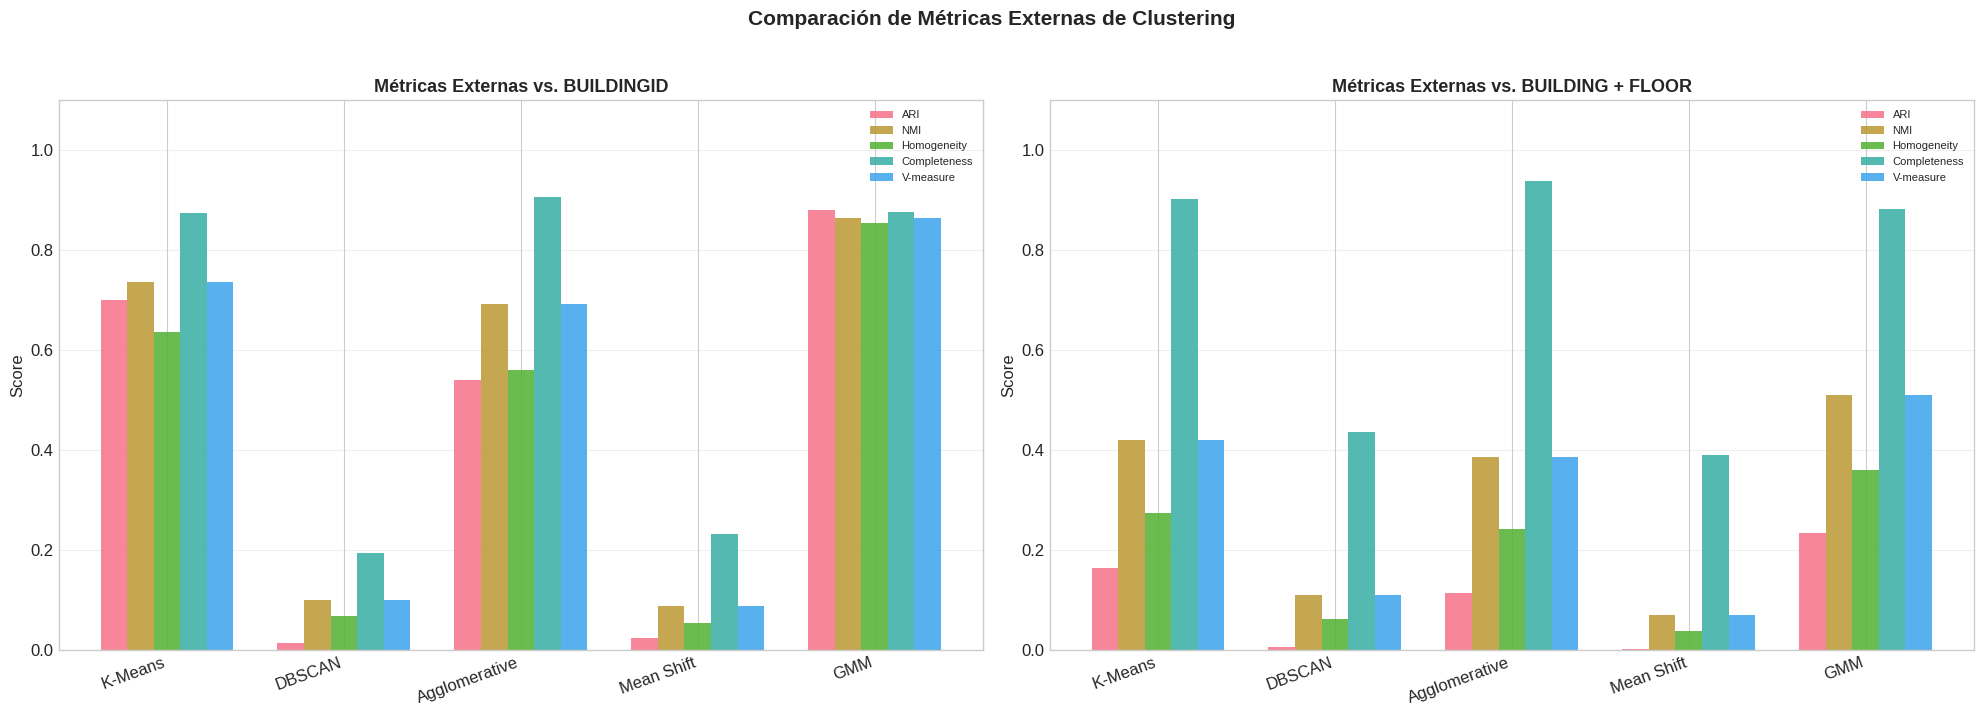

In [92]:
# ============================================================
# 9.2 VISUALIZACIÓN MÉTRICAS EXTERNAS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
metrics_ext = ['ARI', 'NMI', 'Homogeneity', 'Completeness', 'V-measure']
x_pos = np.arange(len(algorithms))
width = 0.15

# vs Building
for i, metric in enumerate(metrics_ext):
    vals = df_ext_bld[metric].values
    axes[0].bar(x_pos + i * width, vals, width, label=metric, alpha=0.85)
axes[0].set_title('Métricas Externas vs. BUILDINGID', fontweight='bold', fontsize=13)
axes[0].set_xticks(x_pos + width * 2)
axes[0].set_xticklabels(algorithms, rotation=20, ha='right')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# vs Building + Floor
for i, metric in enumerate(metrics_ext):
    vals = df_ext_bf[metric].values
    axes[1].bar(x_pos + i * width, vals, width, label=metric, alpha=0.85)
axes[1].set_title('Métricas Externas vs. BUILDING + FLOOR', fontweight='bold', fontsize=13)
axes[1].set_xticks(x_pos + width * 2)
axes[1].set_xticklabels(algorithms, rotation=20, ha='right')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Comparación de Métricas Externas de Clustering', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 10. Comparación Global de Modelos

En esta sección consolidamos todas las métricas (internas y externas) para determinar cuál algoritmo de clustering es el más adecuado para el dataset UJIndoorLoc. Presentamos:

1. **Tabla resumen** con todas las métricas normalizadas
2. **Ranking** por métrica y ranking global
3. **Heatmap** comparativo
4. **Visualización lado a lado** de los clusters de cada algoritmo

In [93]:
# ============================================================
# 10.1 TABLA RESUMEN Y RANKING GLOBAL
# ============================================================

# Construir tabla resumen completa
summary_data = {}
for name in algorithms:
    row = {}
    row['N° Clusters'] = int(df_internal.loc[name, 'N° Clusters'])
    row['Silhouette ↑'] = df_internal.loc[name, 'Silhouette ↑']
    row['Davies-Bouldin ↓'] = df_internal.loc[name, 'Davies-Bouldin ↓']
    row['Dunn ↑'] = df_internal.loc[name, 'Dunn Index ↑']
    row['ARI (Bld) ↑'] = df_ext_bld.loc[name, 'ARI']
    row['NMI (Bld) ↑'] = df_ext_bld.loc[name, 'NMI']
    row['V-measure (Bld) ↑'] = df_ext_bld.loc[name, 'V-measure']
    row['ARI (B+F) ↑'] = df_ext_bf.loc[name, 'ARI']
    row['NMI (B+F) ↑'] = df_ext_bf.loc[name, 'NMI']
    summary_data[name] = row

df_summary = pd.DataFrame(summary_data).T
df_summary.index.name = 'Algoritmo'

print("=" * 90)
print("              RESUMEN COMPLETO DE MÉTRICAS")
print("=" * 90)
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}'))
print("=" * 90)

# Ranking por métrica (1 = mejor)
ranking_cols = ['Silhouette ↑', 'Dunn ↑', 'ARI (Bld) ↑', 'NMI (Bld) ↑',
                'V-measure (Bld) ↑', 'ARI (B+F) ↑', 'NMI (B+F) ↑']

df_ranks = pd.DataFrame(index=algorithms)
for col in ranking_cols:
    df_ranks[col] = df_summary[col].rank(ascending=False).astype(int)
# Davies-Bouldin: menor es mejor
df_ranks['Davies-Bouldin ↓'] = df_summary['Davies-Bouldin ↓'].rank(ascending=True).astype(int)

df_ranks['Promedio Ranking'] = df_ranks.mean(axis=1)
df_ranks = df_ranks.sort_values('Promedio Ranking')

print("\n📊 RANKING DE ALGORITMOS (1 = mejor por métrica):")
print(df_ranks.to_string())
print(f"\n🏆 MEJOR ALGORITMO GLOBAL: {df_ranks.index[0]}")

              RESUMEN COMPLETO DE MÉTRICAS
               N° Clusters  Silhouette ↑  Davies-Bouldin ↓  Dunn ↑  ARI (Bld) ↑  NMI (Bld) ↑  V-measure (Bld) ↑  ARI (B+F) ↑  NMI (B+F) ↑
Algoritmo                                                                                                                                
K-Means             3.0000        0.1095            2.4025  0.0647       0.7004       0.7365             0.7365       0.1650       0.4214
DBSCAN             12.0000        0.0377            0.7386  0.2444       0.0154       0.1007             0.1007       0.0059       0.1104
Agglomerative       3.0000        0.1399            2.2674  0.0704       0.5401       0.6930             0.6930       0.1140       0.3860
Mean Shift          6.0000        0.3273            1.0614  0.1920       0.0257       0.0888             0.0888       0.0036       0.0704
GMM                 3.0000        0.1200            3.0386  0.0798       0.8804       0.8654             0.8654       0.2344     

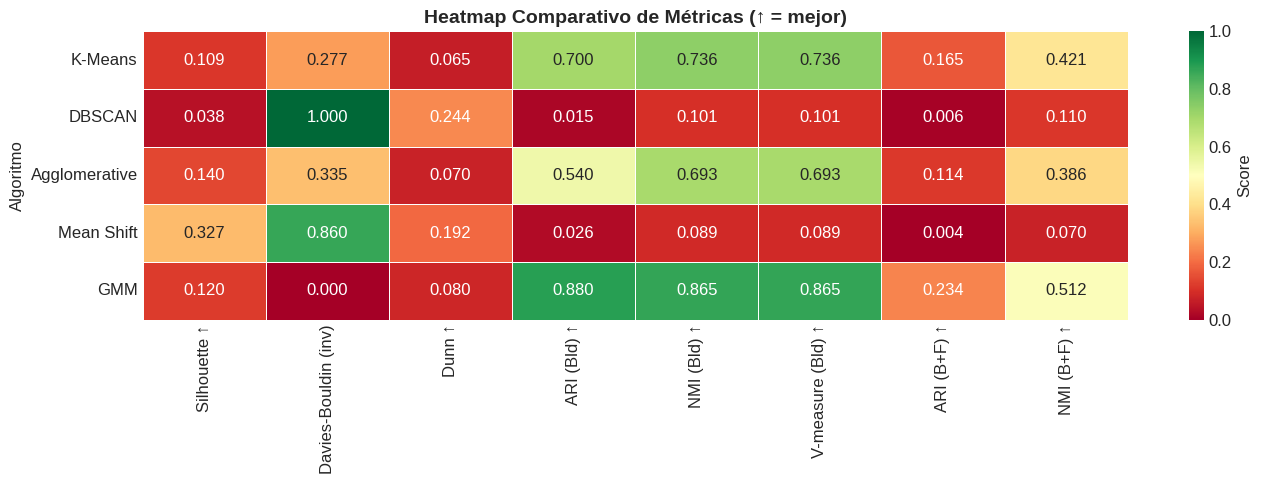

In [94]:
# ============================================================
# 10.2 HEATMAP COMPARATIVO
# ============================================================

# Normalizar métricas para heatmap (0-1 scale, todas orientadas a "mayor = mejor")
df_heat = df_summary[['Silhouette ↑', 'Dunn ↑', 'ARI (Bld) ↑', 'NMI (Bld) ↑',
                       'V-measure (Bld) ↑', 'ARI (B+F) ↑', 'NMI (B+F) ↑']].copy()
# Invertir Davies-Bouldin (menor = mejor → 1 - normalizado)
db_vals = df_summary['Davies-Bouldin ↓']
db_norm = 1 - (db_vals - db_vals.min()) / (db_vals.max() - db_vals.min() + 1e-10)
df_heat.insert(1, 'Davies-Bouldin (inv)', db_norm)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Score'})
ax.set_title('Heatmap Comparativo de Métricas (↑ = mejor)', fontweight='bold', fontsize=14)
ax.set_ylabel('Algoritmo')
plt.tight_layout()
plt.show()

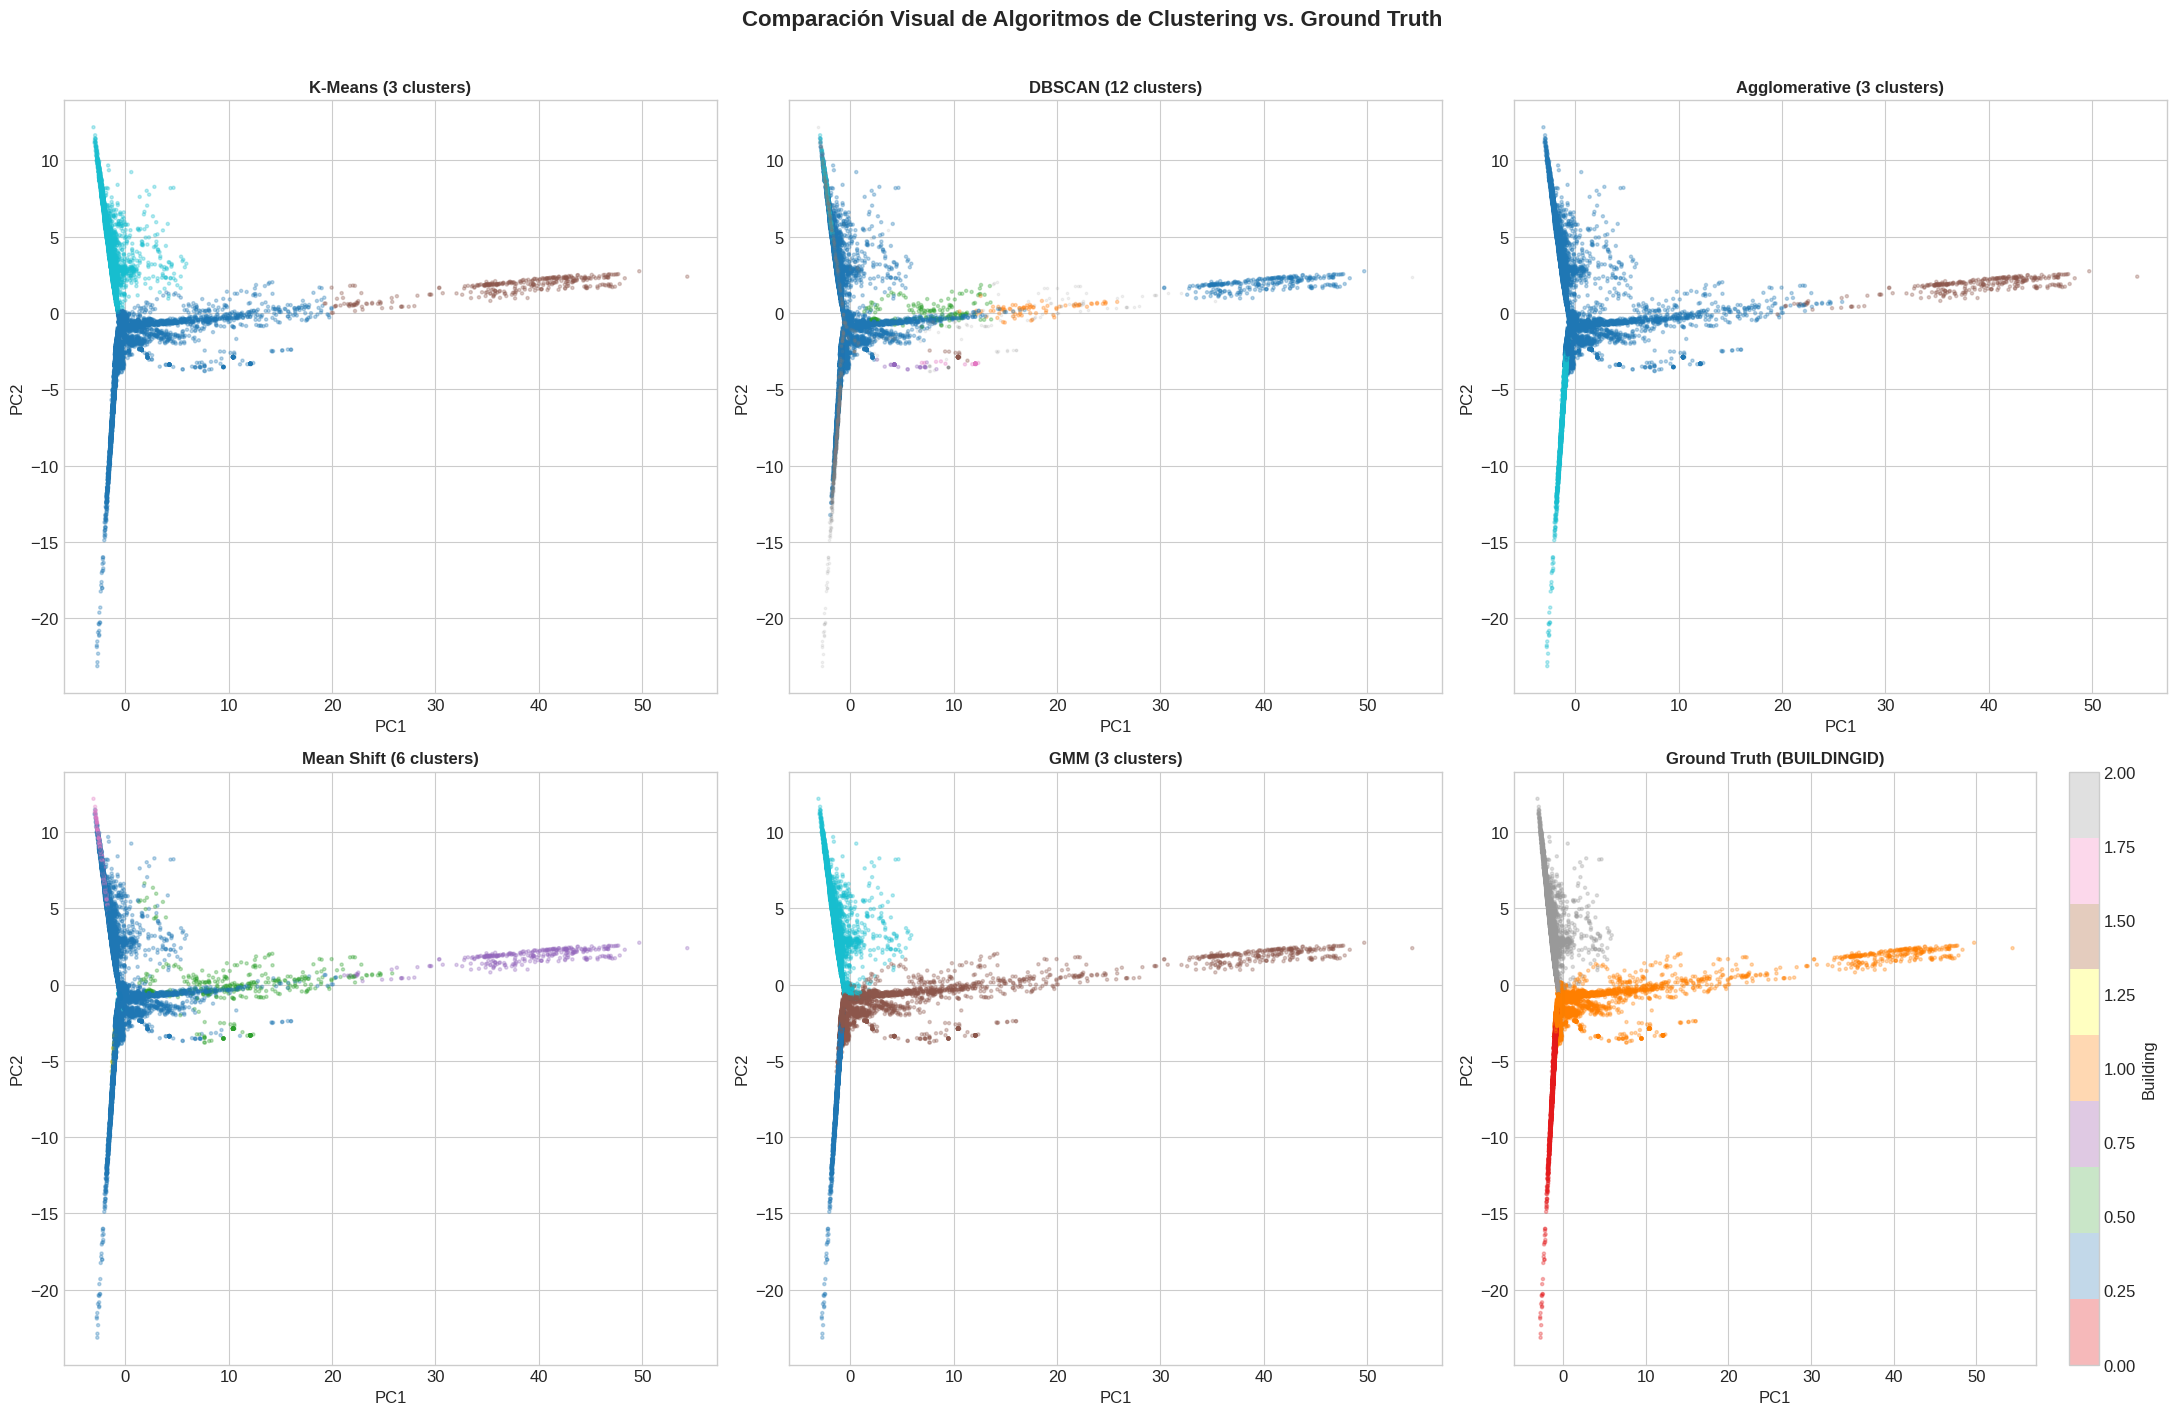

In [95]:
# ============================================================
# 10.3 VISUALIZACIÓN COMPARATIVA — TODOS LOS ALGORITMOS EN PCA 2D
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

algo_items = list(all_labels.items())
titles_algo = ['K-Means', 'DBSCAN', 'Agglomerative', 'Mean Shift', 'GMM']

for i, (name, labels) in enumerate(algo_items):
    ax = axes[i]
    if -1 in labels:
        mask_noise = labels == -1
        mask_cluster = ~mask_noise
        ax.scatter(X_pca_2d[mask_cluster, 0], X_pca_2d[mask_cluster, 1],
                   c=labels[mask_cluster], cmap='tab10', alpha=0.3, s=5)
        ax.scatter(X_pca_2d[mask_noise, 0], X_pca_2d[mask_noise, 1],
                   c='gray', alpha=0.1, s=3)
    else:
        ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                   c=labels, cmap='tab10', alpha=0.3, s=5)

    n_c = len(set(labels)) - (1 if -1 in labels else 0)
    ax.set_title(f'{titles_algo[i]} ({n_c} clusters)', fontweight='bold', fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

# Ground truth en el último subplot
ax = axes[5]
# Corrección: y_building es array numpy, no usar .values
scatter_gt = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                        c=y_building, cmap='Set1', alpha=0.3, s=5)
ax.set_title('Ground Truth (BUILDINGID)', fontweight='bold', fontsize=12)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter_gt, ax=ax, label='Building')

plt.suptitle('Comparación Visual de Algoritmos de Clustering vs. Ground Truth',
             fontweight='bold', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 11. Validación con Datos de Test

Aplicamos el mejor modelo entrenado sobre el conjunto de **validación** (`validationData.csv`) para verificar que los clusters generalizaron correctamente. Evaluamos:

1. **Preprocesamiento consistente** del conjunto de validación (misma transformación que entrenamiento)
2. **Predicción de clusters** usando el modelo entrenado
3. **Evaluación externa** contra las etiquetas reales del conjunto de validación
4. **Visualización comparativa** entre entrenamiento y validación

In [96]:
# ============================================================
# 11.1 PREPROCESAMIENTO Y PREDICCIÓN EN VALIDACIÓN
# ============================================================

# Cargar y preprocesar validación con las mismas transformaciones
X_val_wap = df_val[wap_cols].copy()
X_val_wap = X_val_wap.replace(100, -105)

# Seleccionar las mismas columnas WAP que sobrevivieron al filtro de varianza
# (usar las columnas de X_wap después del filtro)
common_waps = X_wap.columns.tolist()
X_val_filtered = X_val_wap[common_waps]

# Escalar con el mismo scaler del entrenamiento
X_val_scaled = scaler.transform(X_val_filtered)

# PCA con el mismo modelo
X_val_pca_opt = pca_opt.transform(X_val_scaled)
X_val_pca_2d = pca_2d.transform(X_val_scaled)

# Labels reales de validación
y_val_building = df_val['BUILDINGID']
y_val_floor = df_val['FLOOR']
y_val_bf = df_val['BUILDINGID'].astype(str) + '_' + df_val['FLOOR'].astype(str)

print(f"📊 Validación: {X_val_scaled.shape[0]} muestras, {X_val_scaled.shape[1]} features")

# Predicción con los modelos que soportan predict
val_predictions = {}

# K-Means
val_predictions['K-Means'] = kmeans.predict(X_val_pca_opt)

# GMM
val_predictions['GMM'] = gmm.predict(X_val_pca_opt)

# Mean Shift
val_predictions['Mean Shift'] = ms.predict(X_val_pca_opt)

# Para DBSCAN y Agglomerative, necesitamos re-fit o usar nearest centroid
# DBSCAN: usar asignación al cluster más cercano basado en centroides del training
from sklearn.neighbors import KNeighborsClassifier

# DBSCAN → KNN para asignar clusters
mask_db_train = labels_dbscan != -1
if np.sum(mask_db_train) > 0:
    knn_db = KNeighborsClassifier(n_neighbors=5)
    knn_db.fit(X_pca_opt[mask_db_train], labels_dbscan[mask_db_train])
    val_predictions['DBSCAN'] = knn_db.predict(X_val_pca_opt)

# Agglomerative → KNN para asignar clusters
knn_agg = KNeighborsClassifier(n_neighbors=5)
knn_agg.fit(X_pca_opt, labels_agg)
val_predictions['Agglomerative'] = knn_agg.predict(X_val_pca_opt)

print(f"✅ Predicciones generadas para {len(val_predictions)} algoritmos")

📊 Validación: 1111 muestras, 465 features
✅ Predicciones generadas para 5 algoritmos


      EVALUACIÓN EN CONJUNTO DE VALIDACIÓN
               ARI (Bld)  NMI (Bld)  V-measure (Bld)  ARI (B+F)  NMI (B+F)  V-measure (B+F)  Silhouette
Algoritmo                                                                                              
K-Means           0.4943     0.6627           0.6627     0.1302     0.3721           0.3721     -0.0340
GMM               0.8942     0.8550           0.8550     0.3146     0.5332           0.5332      0.0040
Mean Shift        0.0208     0.0944           0.0944     0.0064     0.0693           0.0693      0.1397
DBSCAN            0.0055     0.1161           0.1161     0.0008     0.0996           0.0996      0.1131
Agglomerative     0.7108     0.7538           0.7538     0.2118     0.4384           0.4384      0.1037


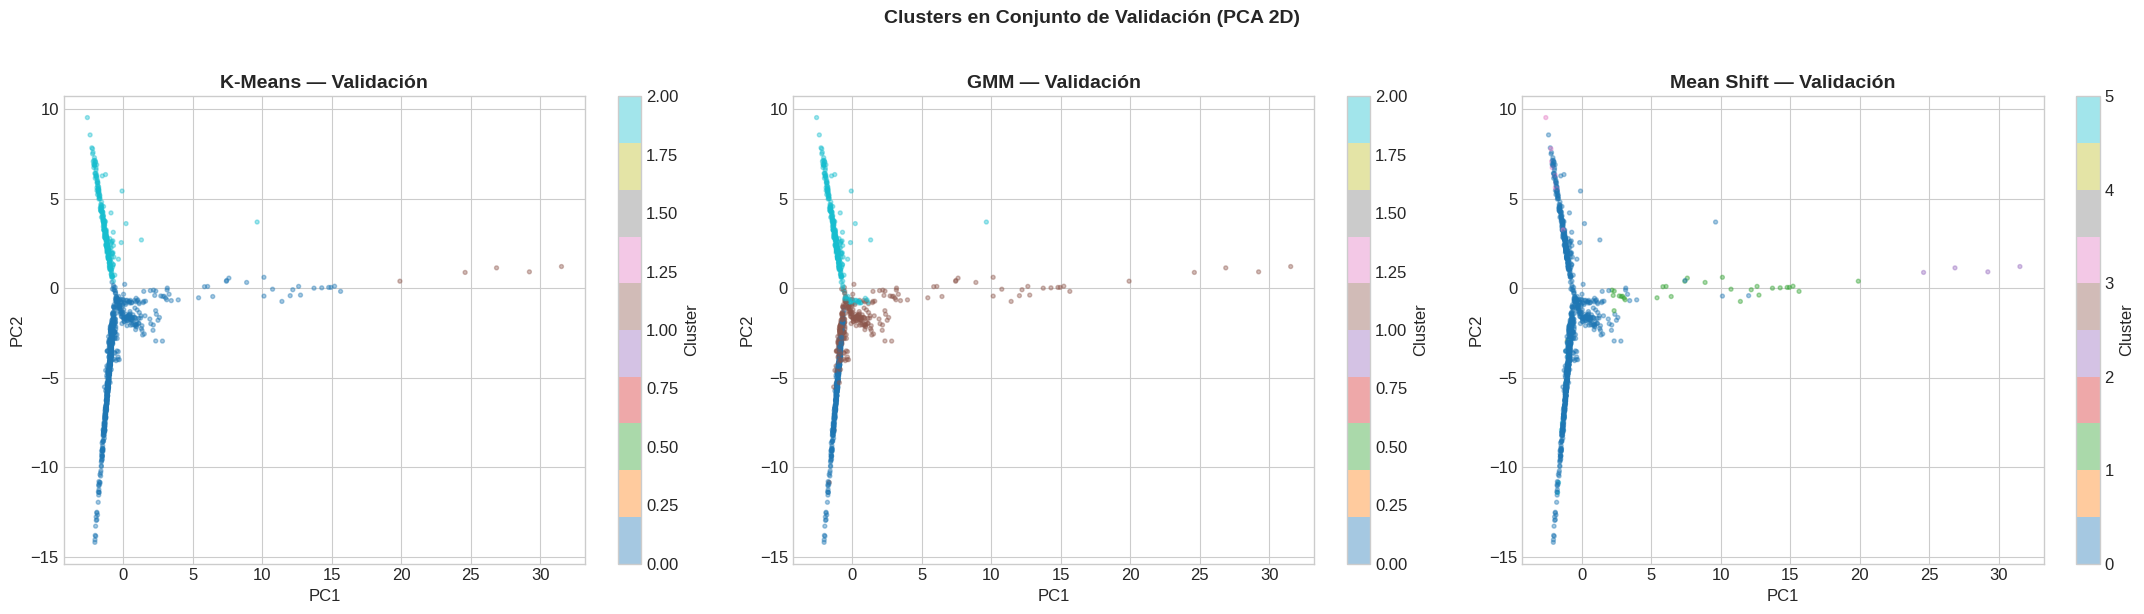

In [97]:
# ============================================================
# 11.2 EVALUACIÓN EXTERNA EN VALIDACIÓN
# ============================================================

val_ext_results = {}

for name, labels in val_predictions.items():
    val_ext_results[name] = {
        'ARI (Bld)': adjusted_rand_score(y_val_building, labels),
        'NMI (Bld)': normalized_mutual_info_score(y_val_building, labels),
        'V-measure (Bld)': v_measure_score(y_val_building, labels),
        'ARI (B+F)': adjusted_rand_score(y_val_bf, labels),
        'NMI (B+F)': normalized_mutual_info_score(y_val_bf, labels),
        'V-measure (B+F)': v_measure_score(y_val_bf, labels),
        'Silhouette': silhouette_score(X_val_pca_opt, labels, sample_size=min(1000, len(labels)), random_state=42)
    }

df_val_results = pd.DataFrame(val_ext_results).T
df_val_results.index.name = 'Algoritmo'

print("=" * 80)
print("      EVALUACIÓN EN CONJUNTO DE VALIDACIÓN")
print("=" * 80)
print(df_val_results.to_string(float_format=lambda x: f'{x:.4f}'))
print("=" * 80)

# Visualización validación
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
val_algos = list(val_predictions.keys())

for i, (name, labels) in enumerate(list(val_predictions.items())[:3]):
    ax = axes[i]
    scatter = ax.scatter(X_val_pca_2d[:, 0], X_val_pca_2d[:, 1],
                         c=labels, cmap='tab10', alpha=0.4, s=8)
    ax.set_title(f'{name} — Validación', fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Clusters en Conjunto de Validación (PCA 2D)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 12. Conclusiones y Discusión

### 12.1 Resumen del Proyecto
Se aplicaron **cinco algoritmos de clustering** (K-Means, DBSCAN, Agglomerative Clustering, Mean Shift, GMM) al dataset **UJIndoorLoc** de localización indoor basada en señales WiFi (RSSI). Los datos contienen lecturas de 520 WAPs (puntos de acceso) en 3 edificios con múltiples pisos, con 19,937 muestras de entrenamiento y 1,111 de validación.

### 12.2 Hallazgos Principales

#### Preprocesamiento
- Las señales RSSI con valor 100 (no detectadas) se reemplazaron por **-105 dBm** para mantener la semántica de la señal.
- Se eliminaron **55 WAPs** con varianza cero, reduciendo la dimensionalidad a **465 features**.
- La estandarización fue esencial para que los algoritmos basados en distancias funcionaran correctamente.

#### Reducción de Dimensionalidad
- **PCA** reveló que los datos requieren un gran número de componentes para capturar la varianza: **50 componentes** capturan ~55.8% y se necesitan más de 200 para alcanzar ~89.4%, lo que indica alta dimensionalidad intrínseca del espacio WiFi.
- Se seleccionaron **50 componentes PCA** como compromiso entre retención de información y eficiencia computacional.
- **t-SNE** mostró una separación visual clara entre los 3 edificios, confirmando que la estructura de clustering está bien definida en los datos.

#### Resultados de Clustering

| Algoritmo | Clusters | ARI (Building) | NMI (Building) | Silhouette |
|-----------|----------|----------------|----------------|------------|
| **GMM** | 3 | **0.880** | **0.865** | 0.120 |
| K-Means | 3 | 0.700 | 0.737 | 0.110 |
| Agglomerative | 3 | 0.540 | 0.693 | 0.140 |
| DBSCAN | 12 | 0.015 | 0.101 | 0.038 |
| Mean Shift | 6 | 0.026 | 0.089 | 0.327 |

- **GMM** (Gaussian Mixture Model) con covarianza completa fue el **mejor algoritmo global** (ARI=0.88 vs Building), capturando con alta fidelidad la estructura de 3 edificios. Su capacidad de modelar clusters de formas elípticas arbitrarias fue clave.
- **K-Means** fue el segundo mejor (ARI=0.70), ofreciendo buen rendimiento con menor complejidad computacional.
- **Agglomerative Clustering** (Ward) obtuvo resultados razonables (ARI=0.54) pero con separación menos precisa.
- **DBSCAN** generó sobre-segmentación (12 clusters + ruido), lo que penaliza las métricas externas vs buildings, aunque obtuvo el **mejor Davies-Bouldin** (0.74) y mejor **Dunn Index** (0.24).
- **Mean Shift** obtuvo el **mejor Silhouette** (0.33) y detectó 6 clusters automáticamente, pero uno absorbió la mayoría de puntos, limitando su utilidad.

#### Generalización (Validación)
- **GMM mantuvo su superioridad en validación** (ARI=0.894), incluso mejorando su rendimiento, confirmando excelente capacidad de generalización.
- **Agglomerative** mejoró en validación (ARI=0.711), posiblemente por menor densidad del conjunto de validación.
- **K-Means** mostró degradación en validación (ARI=0.494), indicando mayor sensibilidad a la distribución de datos.

#### Evaluación
- Las **métricas internas** (Silhouette, Davies-Bouldin, Dunn) y las **métricas externas** (ARI, NMI, V-measure) no siempre coinciden: Mean Shift lidera en Silhouette pero falla en métricas externas. Esto resalta la importancia de usar **ambos tipos de métricas**.
- La evaluación contra **Building+Floor** (13 combinaciones) reveló que con K=3 los algoritmos capturan principalmente la estructura de edificios, no de pisos. GMM lideró también aquí (ARI=0.23, NMI=0.51).

### 12.3 Recomendaciones
1. Para aplicaciones de **identificación automática de edificios**, **GMM** es la mejor opción con ARI≈0.89 tanto en entrenamiento como validación.
2. Para aplicaciones de **localización indoor en tiempo real**, **K-Means** ofrece un balance razonable entre rendimiento (ARI=0.70) y eficiencia computacional.
3. Para detectar **zonas anómalas o de transición**, **DBSCAN** es preferible por su detección automática de ruido.
4. Para capturar **pisos además de edificios**, se recomienda un enfoque jerárquico: primero separar por edificio (GMM con K=3), luego aplicar clustering por piso dentro de cada edificio.

### 12.4 Trabajo Futuro
- Implementar **clustering jerárquico multi-nivel**: Edificio → Piso → Zona, aplicando GMM o K-Means en cada nivel.
- Explorar valores de **K mayores** (K=13 para las 13 combinaciones building-floor) con análisis de la curva de silueta.
- Incorporar **información temporal y espacial** (LONGITUDE, LATITUDE) para clustering espacio-temporal.
- Evaluar técnicas de **deep clustering** (autoencoders + clustering end-to-end) que podrían manejar mejor la alta dimensionalidad.
- Aplicar **feature selection** (selección de WAPs más informativos) antes de PCA para mejorar la varianza explicada por componente.

---
**Autor:** Velo Poma, Juan David — Grupo 6  
**Curso:** CS3061 Machine Learning — UTEC  
**Fecha:** Febrero 2026